# Network Experiment

This module is a testground for exploring the nonnormal network. 

In [ ]:
# automatic reload: 
%load_ext autoreload
%autoreload 2
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
from importlib import reload
from Network_models import DynamicalNetwork as d
from Plots import globe_plots as gp
torch.set_default_dtype(torch.float32)
from utils.path_settings import *
from Network_models.FMTrainer import FMTrainer
from pytorch3d.io import load_objs_as_meshes
import gc
from SimulateDatasets.CubeMesh import CubeMesh
from Network_models.CTrainer import CTrainer
from SimulateDatasets.CubeMesh import CubeMesh
from utils.path_settings import *


/home/timmy/nonnormal/dummy/mental-rotations


2024-12-25 05:55:29.929159: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-25 05:55:29.947070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-25 05:55:29.973976: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-25 05:55:29.974049: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-25 05:55:29.991854: I tensorflow/core/platform/cpu_feature_gua

loading


In [23]:
tau = 100
dt = 1
resolution = 256
dT = 500/16
mode = "full"
model = torch.load(MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_5_train_10_8_cube_{mode}/model.pth")
model = model.predictor
cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
torch.save(cube, cube_path)
decoder_specs = None
batch_size = 8096
mini_batch_size = 2048
model_specs = {
    "model_name": "ControlInjectNet",
    "model_path": "Network_models.PIDController",
    "model_params":{
        "tau": tau, 
        "dt": dt, 
        "dT": dT,
        "predictive_model": model,
        "output_size": 16 if mode == "camera_simple" else 24,
        "target_size": 200,
        "pure_error": False, 
        "activation": "relu",
        "hidden_control_dim": 128, 
    }
}

dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
        "stepwise": True
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.0002,
    }
}

data_loader_configs = {
    "batch_size": 8192,
    "mini_batch_size": 8192,
    "encoder_specs": None,
    "target_seq_len": 5,
    "object_path": cube_path,
}

config = {
    "model_specs": model_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "control_period": 16,
    "random_initial_condition": True,
    "additional_loss": ["control_norm"], # choices: "state_norm", "control_norm", "state_likelihood"
    "data_loader_configs": data_loader_configs,
}

additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") + ("_" if len(config['additional_loss']) else "") + "_".join(config["additional_loss"])
model_path = f"/controller/{model_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = config | {
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

import time
print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}"), "state_norm"
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 10,
    "epochs": 300, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data_stepwise_cube" + (("_" + mode) if mode != "" else "") +  "/",
    "verbose": True,
    "replacement_tolerance": 0.1,
}

trainer = CTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
print(f"tensorboard --logdir {config['log_path']}")
# trainer.train(**training_args)

batch_size: 8096, mini_batch_size: 2048
no scheduler
['control_norm']
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/controller/ControlInjectNet_dynamics_0.07Linear_cube_full_control_norm//


In [28]:
constraints = [
    [], 
    ['control_norm'],
    # ["control_norm", "state_likelihood"],
    ["state_norm"],
    ["control_norm", "state_norm"]
    ]
# name_appendix = ["", "control_norm", "control_norm_state_likelihood", "state_norm", "control_norm_state_norm"]
mode = "camera_simple"
for ind, loss in enumerate(constraints):
    tau = 100
    dt = 1
    resolution = 256
    dT = 500/16
    model = torch.load(MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_5_train_10_8_cube_{mode}/model.pth")
    model = model.predictor
    cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
    cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
    torch.save(cube, cube_path)
    decoder_specs = None
    batch_size = 8096
    mini_batch_size = 2048
    model_specs = {
        "model_name": "ControlInjectNet",
        "model_path": "Network_models.PIDController",
        "model_params":{
            "tau": tau, 
            "dt": dt, 
            "dT": dT,
            "predictive_model": model,
            "output_size": 16 if mode == "camera_simple" else 24,
            "target_size": 200,
            "pure_error": False, 
            "activation": "relu",
            "hidden_control_dim": 128, 
        }
    }

    dynamics_model_specs = {
        "model_name": "DynamicalNetwork", 
        "model_path": "Network_models.DynamicalNetwork", 
        "model_params": {
            "output_size": 3, 
            "freeze_C": True, 
            "mode": "initial_condition", 
            "tau": tau,
            "dt": dt, 
            "seed": 10, 
            "total_period": 1000, 
            "action_period": 500, 
            "out_accel": True,
            "optimise_C": True,
            "automatically_plot": False, 
            "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
            "tau_accel": 50,
            "input_scalar": 0.07,
            "stepwise": True
        },
    }

    optimizer_specs = {
        "optimizer_name": "Adam",
        "optimizer_params": {
            "lr": 0.0002,
        }
    }

    data_loader_configs = {
        "batch_size": 8192,
        "mini_batch_size": 8192,
        "encoder_specs": None,
        "target_seq_len": 5,
        "object_path": cube_path,
    }

    config = {
        "model_specs": model_specs,
        "dynamics_model_specs": dynamics_model_specs,
        "optimizer_specs": optimizer_specs,
        "control_period": 16,
        "random_initial_condition": True,
        "additional_loss": loss, # choices: "state_norm", "control_norm", "state_likelihood"
        "data_loader_configs": data_loader_configs,
    }

    additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") + ("_" if len(config['additional_loss']) else "") + "_".join(config["additional_loss"])
    model_path = f"/controller/{model_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

    config = config | {
        "save_path": MODEL_SAVE_PATH + model_path + "/",
        "check_path": MODEL_SAVE_PATH + model_path + "/",
        "log_path": LOG_PATH + model_path + "/",
    }

    import time
    print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}")
    training_args = {
        "batch_size": batch_size, 
        "mini_batch_size": mini_batch_size, 
        "epochs_to_calculate": 10,
        "epochs": 300, 
        "load_upper": 47,
        "save_interval": 10, 
        "reset_interval": 200,
        "early_stop": False,
        "data_save_path": DATA_PATH + f"/forward_model_data_stepwise_cube" + (("_" + mode) if mode != "" else "") +  "/",
        "verbose": True,
        "replacement_tolerance": 0.1,
    }

    trainer = CTrainer(config)
    time_start = time.time()

    for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
        os.makedirs(path, exist_ok = True)
    training_args['save_path'] = config["save_path"] + "model.pth"
    training_args["data_loader_configs"] = data_loader_configs
    print(f"tensorboard --logdir {config['log_path']}")
    trainer.train(**training_args)

batch_size: 8096, mini_batch_size: 2048
no scheduler
[]
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/controller/ControlInjectNet_dynamics_0.07Linear_cube_camera_simple//
batch_size: 8096, mini_batch_size: 2048
Loading train_0.pth
8192
0
Loading val_0.pth
1024
0
Epoch 0, learning rate: 0.0002
Epoch 0, training loss: 4.68585205078125, validation loss: 3.932570457458496
Epoch 1, training loss: 3.630704879760742, validation loss: 3.2743496894836426
Epoch 2, training loss: 3.0487141609191895, validation loss: 2.6807847023010254
Epoch 3, training loss: 2.5302469730377197, validation loss: 2.2842283248901367
Epoch 4, training loss: 2.224135637283325, validation loss: 2.072176694869995
Epoch 5, training loss: 1.9972199201583862, validation loss: 1.8912348747253418
Epoch 6, training loss: 1.8160983324050903, validation loss: 1.7700868844985962
Epoch 7, training loss: 1.6774020195007324, validation loss: 1.6344823837280273
Epoch 8, training loss: 1.5477118492126465, val

/controller/ControlInjectNet_dynamics_0.07Linear_cube_full_control_norm_state_norm/model.pth
Generating 1 samples
Output acceleration
Time for forward network dynamics : 0.21022891998291016
Time for rendering the dataset: 0.0017290115356445312
torch.Size([1, 5, 24])


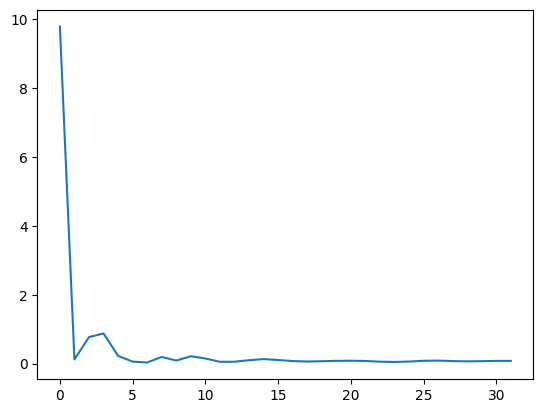

In [99]:
import matplotlib.pyplot as plt

model_name = "ControlInjectNet"
input_scalar = 0.07
additional_constraint = ["control_norm", "state_norm"]
additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") +  ("_" if len(additional_constraint) > 0 else "") +"_".join(additional_constraint)
model_path = f"/controller/{model_name}_dynamics_{input_scalar}{additional_name if additional_name is not None else ""}/model.pth"
print(model_path)
controller = torch.load(MODEL_SAVE_PATH + model_path)

# design a simple cube objective and see if the above controller works!
z0 = torch.zeros(1, 200, device = "cuda")
trainer.data_gen.cubemesh = True
target = trainer.data_gen.generate_data(1)
print(target.I.shape)
controller_results = controller.forward(z0, target.I[..., -1, :], control_period = 32, control_threshold = None, period_upperlimit = 10000, return_control_trajectory=True)
plt.plot(controller_results[2].cpu().detach().numpy().transpose())

plot actual dynamics

Generating 1 samples
Output acceleration
Time for forward network dynamics : 0.16326546669006348
Time for rendering the dataset: 0.001247406005859375
torch.Size([1, 33, 200])
Output acceleration


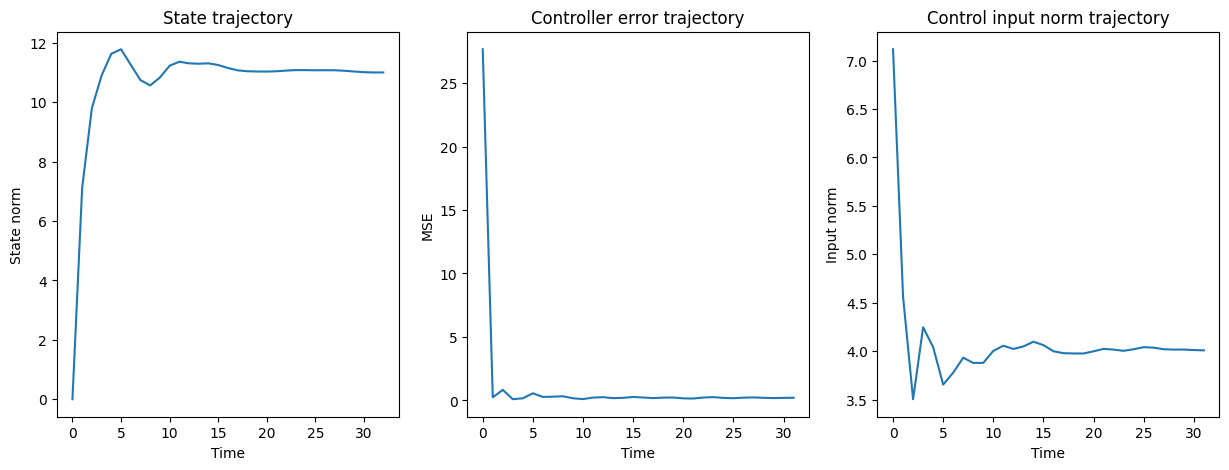

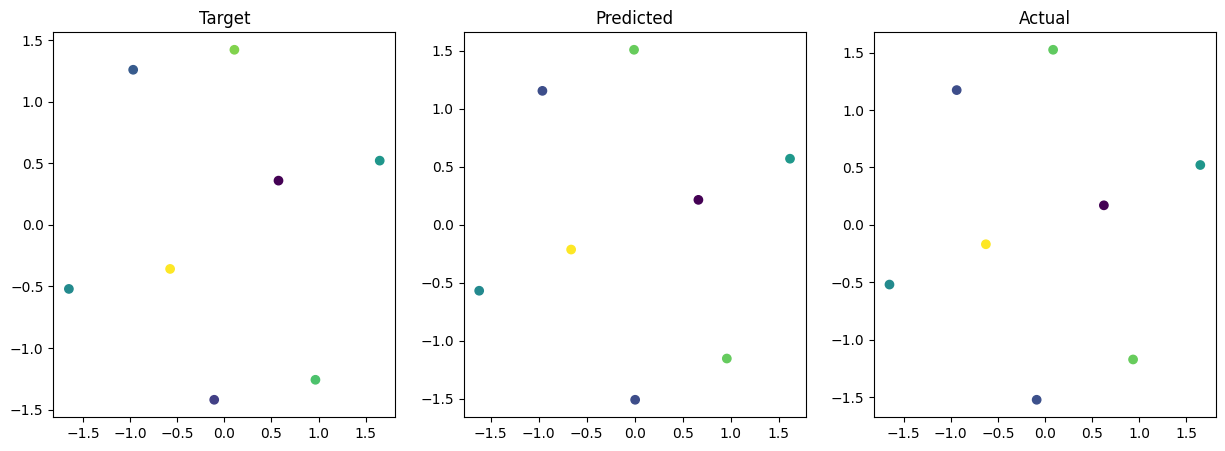

In [101]:
import numpy as np
z0 = torch.zeros(1, 200, device = "cuda")
trainer.data_gen.cubemesh = True
target = trainer.data_gen.generate_data(1)

fig, ax1 = plt.subplots(1, 3, figsize = (15, 5))

controller_results = controller.forward(z0, target.I[..., -1, :], control_period = 32, control_threshold = None, period_upperlimit = 10000, return_control_trajectory=True)
ax1[0].plot(controller_results[0].norm(dim=-1).cpu().detach().numpy().transpose())
ax1[0].set_title("State trajectory")
ax1[0].set_ylabel("State norm")
ax1[0].set_xlabel("Time")

ax1[1].plot((controller_results[2].cpu().detach().numpy().transpose()))
ax1[1].set_title("Controller error trajectory")
ax1[1].set_ylabel("MSE")
ax1[1].set_xlabel("Time")

print(controller_results[0].shape)
# also plot the control magnitude and x magnitude
ax1[2].plot((controller_results[1].norm(dim=-1).cpu().detach().numpy().transpose()))
ax1[2].set_title("Control input norm trajectory")
ax1[2].set_ylabel("Input norm")
ax1[2].set_xlabel("Time")

# see the actual rotation vs. a rotation from the controller: 
shape = (-1, 8, 3) if mode != "camera_simple" else (-1, 8, 2)
pred_out = controller.predictive_model(controller_results[0][:, -1, :].detach()).reshape(*shape)[-1,...].detach()
out = controller.dynamics_model(controller_results[0][:, -1, :].detach() * controller.dynamics_model.input_scalar)
q = controller.dynamics_model.pred[:, -1, :].detach()
if mode != "camera_simple":
    I = trainer.data_gen.mesh.quat2verts(q/q.norm(dim = -1, keepdim = True), mode).reshape(8, 3)
    targ = target.I[..., -1, :].reshape(8, 3)

    #plot the actual rotation
    fig, ax = plt.subplots(1, 3, figsize = (15, 5))
    ax[0].scatter(targ[:, 0].cpu().numpy(), targ[:, 1].cpu().numpy(), c = targ[:, 2].cpu().numpy())
    ax[0].set_title("Target")

    ax[1].scatter(pred_out[:, 0].cpu().numpy(), pred_out[:, 1].cpu().numpy(), c = pred_out[:, 2].cpu().numpy())
    ax[1].set_title("Predicted")

    ax[2].scatter(I[:, 0].cpu().numpy(), I[:, 1].cpu().numpy(), c = I[:, 2].cpu().numpy())
    ax[2].set_title("Actual")
else: 
    I = trainer.data_gen.mesh.quat2verts(q/q.norm(dim = -1, keepdim = True), mode).reshape(8, 2)
    targ = target.I[..., -1, :].reshape(8, 2)

    #plot the actual rotation
    fig, ax = plt.subplots(1, 3, figsize = (15, 5))
    ax[0].scatter(targ[:, 0].cpu().numpy(), targ[:, 1].cpu().numpy())
    ax[0].set_title("Target")

    ax[1].scatter(pred_out[:, 0].cpu().numpy(), pred_out[:, 1].cpu().numpy())
    ax[1].set_title("Predicted")

    ax[2].scatter(I[:, 0].cpu().numpy(), I[:, 1].cpu().numpy())
    ax[2].set_title("Actual")

# Formal start on this notebook


Define dynamics

$$
\tau \dot{\mathbf{x}} = -\mathbf{x} + \mathbf{I} + W \Delta \mathbf{r} (\mathbf{x}, t)\\
$$

# Now inspect the range of final outputs produced

Output acceleration


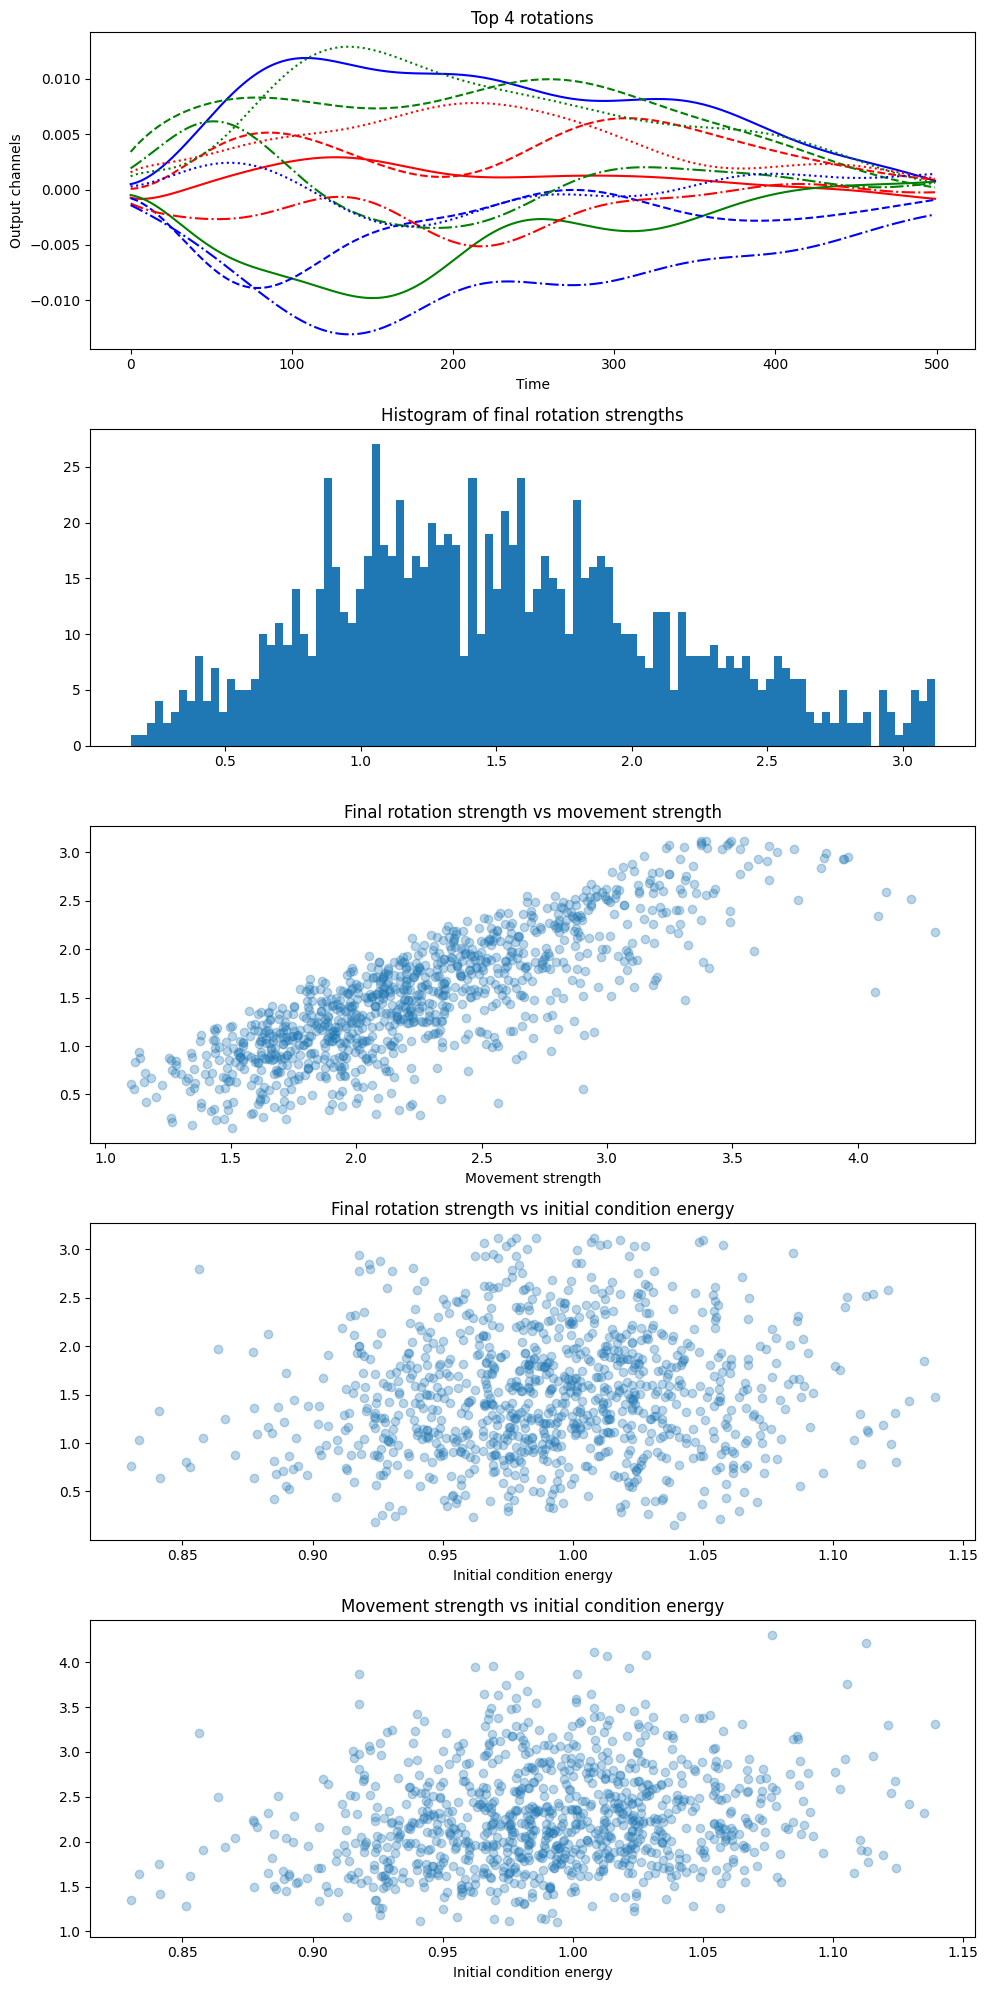

In [7]:
scale = 1
dt = 1 * scale
tau = 100 * scale
for input_scalar in [0.07]:#, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]: 
    network_params = {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": input_scalar,
        "stepwise": True, 
    }
    network = d.DynamicalNetwork(network_params)
    # network.k = 0.01
    # network.eval_k()
    sample = network.sample_initial_condition(1000, use_gramian = True)
    results = network(sample * network.input_scalar)
    final_rotations = network.pred.cpu().numpy() if len(network.pred.shape) == 2 else network.pred[:, -1, :].cpu().numpy()
    # Convert quaternions to theta and u
    # Convert quaternions to standard form (positive real part): 
    for i in range(final_rotations.shape[0]):
        if final_rotations[i, 0] < 0:
            final_rotations[i] = -final_rotations[i]
    theta = np.arccos(final_rotations[:, :1]) * 2
    u = final_rotations[:, 1:] / np.sin(theta / 2)
    xs = 0.5 * u * theta
    Y = [network.out.norm(p = 2, dim = (-1)).cpu().numpy().sum(axis = 1)]
    # gp.plot_generic(xs, Y, ["Final rotations"], show = True, colorscale = "gnbu")
    top_indices = np.argsort(-Y[0])[:4]
    linestyles = ["-", "--", "-.", ":"]
    colors = ["r", "g", "b"]
    fig, ax = plt.subplots(5, 1, figsize = (10, 20))
    for i, idx in enumerate(top_indices):
        for j in range(3):
            ax[0].plot(
                results[idx, :, j].cpu().detach().numpy(),
                linestyle=linestyles[i % 4],
                c=colors[j],
            )
    ax[0].set_title("Top 4 rotations")
    ax[0].set_xlabel("Time")
    ax[0].set_ylabel("Output channels")

    # use Ax 2 to plot a hist of thetas
    ax[1].hist(theta, bins=100)
    ax[1].set_title("Histogram of final rotation strengths")

    # use Ax 2 to plot relationship between movement strength and final rotation strength
    ax[2].scatter(Y[0], theta, alpha=0.3)
    ax[2].set_title("Final rotation strength vs movement strength")
    ax[2].set_xlabel("Movement strength")

    # use Ax 3 to plot relationship between initial condition norm and final rotation strength
    ax[3].scatter(network.input_scalar * sample.norm(p = 2, dim = (-1)).cpu().numpy(), theta, alpha=0.3)
    ax[3].set_title("Final rotation strength vs initial condition energy")
    ax[3].set_xlabel("Initial condition energy")

    # use Ax 4 to plot relationship between initial condition norm and movement strength
    ax[4].scatter(network.input_scalar * sample.norm(p = 2, dim = (-1)).cpu().numpy(), Y[0], alpha = 0.3)
    ax[4].set_title("Movement strength vs initial condition energy")
    ax[4].set_xlabel("Initial condition energy")
    fig.tight_layout()
    # save pic
    os.makedirs(FIG_PATH + "/dynamic_trajectory", exist_ok = True)
    plt.savefig(FIG_PATH + f"/dynamic_trajectory/scalar={network_params['input_scalar']}.png")
# torch.save(network, MODEL_SAVE_PATH + "/dynamics_network.pth")

# Try discretisation

In [27]:
one_sample = network.sample_initial_condition(1, use_gramian=True)
results = network(one_sample * network.input_scalar)
x = network.discretise(one_sample * network.input_scalar, 500/32, 32)

Output acceleration


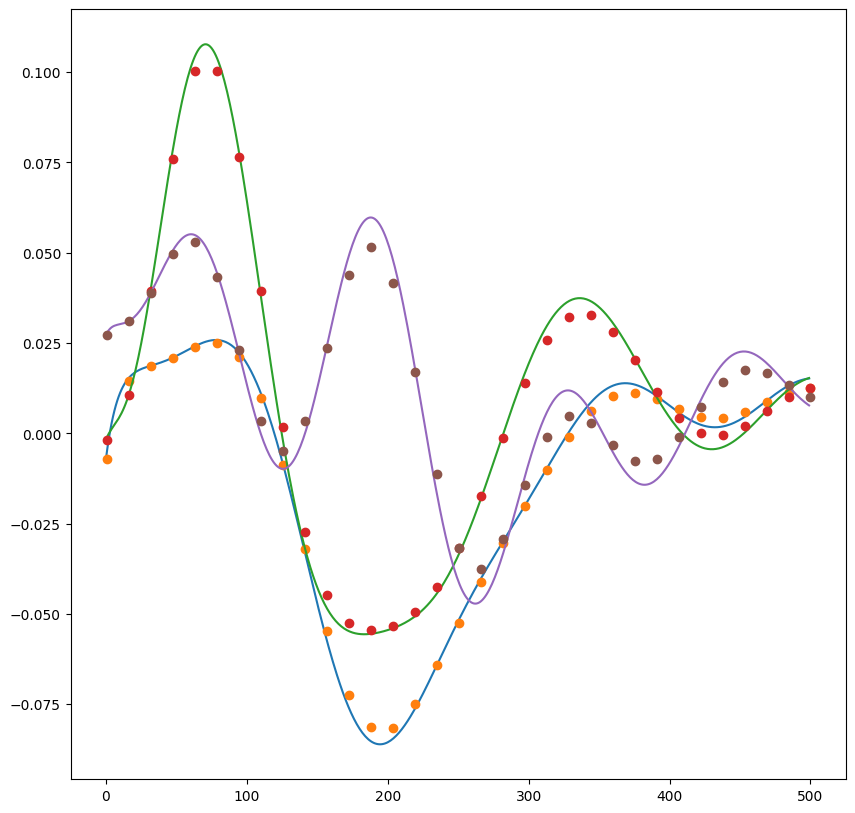

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
for i in range(3): 
    ax.plot(
        network.z[0, :, i].cpu().detach().numpy(),
    )
    ax.plot(
        np.linspace(1, 500, 33), x[:, i].cpu().detach().numpy(), "o"
    )

# Experiment with training a forward model!

## 1. Simplest setup: invert the pretrain task

In [ ]:
tau = 100
dt = 1
# loss = "Predictor-Geodesic"
encoder_specs = None
decoder_specs = None
additional_name = "input_time_10_silence_5"
predictor_specs = {
    "model_name": "FastRecurrence", 
    "model_path": "Network_models.ForwardModels", 
    "model_params": {
        "input_size": 200, 
        "output_size": 4, 
        "hidden_sizes": [256],
        "input_presentation_time": 10,
        "silence_time": 10,
        "RNN_type": "GRU", 
        "flatten_readout": False,
        "RNN_params": {
            "hidden_size": 200, 
            "num_layers": 1, 
            "batch_first": True, 
        },
        "linear_params": {
            "hidden_sizes": [
                32,
            ],
        },
    },
    "frozen": False, 
}
dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.01,
    }
}

data_loader_configs = {
    "batch_size": batch_size,
}

loss = "Predictor-GeoGradual"
if loss == "Predictor-GeoGradual": 
    dynamics_model_specs['model_params']['stepwise'] = True
    assert predictor_specs['model_params']['silence_time'] > 1
    additional_name = additional_name + "_stepwise"
    predictor_specs['model_params']['stepwise'] = True
    # data_loader_configs["target_seq_len"] = predictor_specs['model_params']['silence_time']
    data_loader_configs["target_seq_len"] = dynamics_model_specs['model_params']['action_period']

model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "encoder_specs": encoder_specs,
    "decoder_specs": decoder_specs,
    "predictor_specs": predictor_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

batch_size = 2048
import time
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": batch_size, 
    "epochs_to_calculate": 20,
    "loss": loss, 
    "epochs": 2000, 
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss == "Predictor-GeoGradual" else ""}",
    "verbose": False,
}

trainer = FMTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
trainer.config['training_config'] = training_args
print(f"tensorboard --logdir {config['log_path']}")
trainer.train_fm(**training_args)
time_end = time.time()
print(f"Time taken: {time_end - time_start}")

tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-GeoGradual/FastRecurrence_dynamics_0.07input_time_10_silence_5_stepwise//
predictor is now unfrozen.
Loading train_0.pth
Loading val_0.pth
torch.Size([2048, 200])
torch.Size([2048, 200])
torch.Size([2048, 500, 4])
Epoch 0, learning rate: 0.01
torch.Size([205, 200])
torch.Size([205, 500, 4])
torch.Size([2048, 200])
torch.Size([2048, 200])
torch.Size([2048, 500, 4])
torch.Size([205, 200])
torch.Size([205, 500, 4])
torch.Size([2048, 200])
torch.Size([2048, 200])
torch.Size([2048, 500, 4])
torch.Size([205, 200])
torch.Size([205, 500, 4])
torch.Size([2048, 200])
torch.Size([2048, 200])
torch.Size([2048, 500, 4])
torch.Size([205, 200])
torch.Size([205, 500, 4])
torch.Size([2048, 200])
torch.Size([2048, 200])
torch.Size([2048, 500, 4])
torch.Size([205, 200])
torch.Size([205, 500, 4])
torch.Size([2048, 200])
torch.Size([2048, 200])
torch.Size([2048, 500, 4])
torch.Size([205, 200])
torch.Size([205, 50

KeyboardInterrupt: 

In [ ]:
torch.save(trainer.model, config["save_path"] + "best_model.pth")

In [ ]:
# Use this block if you want to keep training the trainer defined above
time_start = time.time()
trainer.load_checkpoint(config["check_path"] + "checkpoint1499.pth")
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": batch_size, 
    "epochs_to_calculate": 10,
    "loss": loss, 
    "epochs": 1500, 
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss == "Predictor-GeoGradual" else ""}",
    "verbose": False,
    "load_index": {
        "train": 0, 
        "val": 0
    }, 
    "store_index": {
        "train": 0, 
        "val": 0
    },

}
for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
trainer.config['training_config'] = training_args
print(f"tensorboard --logdir {config['log_path']}")
trainer.train(**training_args)
time_end = time.time()
print(f"Time taken: {time_end - time_start}")

tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-GeoGradual/FastRecurrence_dynamics_0.07input_time_10_silence_5_stepwise//
Target sequence length: 500
Output acceleration
Output acceleration
Epoch 0, learning rate: 0.01
Loading train_0.pth
Loading val_0.pth
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Epoch 100, learning rate: 0.01
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Epoch 200, learning rate: 0.01
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Epoch 300, lea

# Pre-setting the data

So the above works as a model. However, the model is incredibly data-hungry - basically, every successful integration requires integration of new datapoints. For the actual task with predicting encoded versions of rendered images, we will have to use a more data-efficient approach, as we will rely on pre-made datapoints. 

Hence, several directions to try out: 

- Does simply using more datapoints work? 
- Does the observed model improvement with more data hold if the new data is a randomly sampled subset of previously seen data? (let's cycle say 20 datasets of 1000 points, and see if the model improves analogously)
- This seems to diverge a bit from mini-batching: overtraining is an issue, so unseen datapoints may be important. The question is how long the model has old datapoints in "memory". 

...

In [ ]:
tau = 100
dt = 1
# loss = "Predictor-Geodesic"
encoder_specs = None
decoder_specs = None
additional_name = "input_time_10_silence_5_train_10_8"
batch_size = 8192
predictor_specs = {
    "model_name": "FastRecurrence", 
    "model_path": "Network_models.ForwardModels", 
    "model_params": {
        "input_size": 200, 
        "output_size": 4, 
        "hidden_sizes": [256],
        "input_presentation_time": 10,
        "silence_time": 5,
        "RNN_type": "GRU", 
        "flatten_readout": False,
        "RNN_params": {
            "hidden_size": 200, 
            "num_layers": 1, 
            "batch_first": True, 
        },
        "linear_params": {
            "hidden_sizes": [
                32,
            ],
        },
    },
    "frozen": False, 
}
dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.008,
    }
}

data_loader_configs = {
    "batch_size": batch_size,
}

loss = "Predictor-GeoGradual"
if loss == "Predictor-GeoGradual": 
    dynamics_model_specs['model_params']['stepwise'] = True
    assert predictor_specs['model_params']['silence_time'] > 1
    additional_name = additional_name + "_stepwise"
    predictor_specs['model_params']['stepwise'] = True
    # data_loader_configs["target_seq_len"] = predictor_specs['model_params']['silence_time']
    data_loader_configs["target_seq_len"] = dynamics_model_specs['model_params']['action_period']

model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "encoder_specs": encoder_specs,
    "decoder_specs": decoder_specs,
    "predictor_specs": predictor_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

import time
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": 512, 
    "epochs_to_calculate": 8,
    "loss": loss, 
    "epochs": 630, 
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss == "Predictor-GeoGradual" else ""}",
    "verbose": True,
    "replacement_tolerance": 0.5,
}

trainer = FMTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
trainer.config['training_config'] = training_args
print(f"tensorboard --logdir {config['log_path']}")
trainer.train_fm(**training_args)
time_end = time.time()

tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-GeoGradual/FastRecurrence_dynamics_0.07input_time_10_silence_5_train_10_8_stepwise//
predictor is now unfrozen.
Loading train_0.pth
Loading val_0.pth
Epoch 0, learning rate: 0.008
Epoch 0, training loss: 4.941885948181152, validation loss: 3.3222928047180176
Epoch 1, training loss: 2.8601651191711426, validation loss: 2.3450839519500732
Epoch 2, training loss: 1.8957793712615967, validation loss: 1.6892218589782715
Epoch 3, training loss: 1.418215274810791, validation loss: 1.4097638130187988
Epoch 4, training loss: 1.192948341369629, validation loss: 1.370315432548523
Epoch 5, training loss: 1.0314970016479492, validation loss: 1.2481184005737305
Epoch 6, training loss: 0.9266453981399536, validation loss: 1.2322123050689697
Epoch 7, training loss: 0.8959752917289734, validation loss: 1.2354106903076172
Epoch 8, training loss: 0.8124057054519653, validation loss: 1.195199966430664
Epoch 9, t

Handcrafting a best combination (as above) (we can probably improve a bit further by introducing LR scheduling towards the end, but the simple one is good enough). 
- we required 43 batches of data to train
- each data contained 8192\*500\*4 + 8192\*200 + 8192\*200 ~ 20M datapoints
- this converts to 43 * 20M = 860M datapoints, accounting for 43 * 72100000 bytes = 3.1GB of data.

Let's assume we want to have images as encodings: 
- 8192\*10\*64\*63 + 8192\*200 + 8192\*4 = 337M datapoints
- Apply this scalar: we would have to 17.8 * 3.1 = 55GB of data.

Is this a bit too much?

# Try PCA for encoding
Using PCA for encoding is a very simple way to reduce the dimensionality of the data and hence the space I need.

Let's first investigate the use of PCA:
- use stochastic SVD
- investigate the effect of number of components on explained variance



In [ ]:
# HIDE CODE
# use a placeholder trainer object to generate sample data 
tau = 100
dt = 1
# loss = "Predictor-Geodesic"
encoder_specs = None
decoder_specs = None
additional_name = "input_time_10_silence_5_train_10_8_"
batch_size = 16
mini_batch_size = 4
predictor_specs = {
    "model_name": "FastRecurrence", 
    "model_path": "Network_models.ForwardModels", 
    "model_params": {
        "input_size": 200, 
        "output_size": 4, 
        "hidden_sizes": [256],
        "input_presentation_time": 10,
        "silence_time": 10,
        "RNN_type": "GRU", 
        "flatten_readout": False,
        "RNN_params": {
            "hidden_size": 200, 
            "num_layers": 1, 
            "batch_first": True, 
        },
        "linear_params": {
            "hidden_sizes": [
                32,
            ],
        },
    },
    "frozen": False, 
}
dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.008,
    }
}

data_loader_configs = {
    "batch_size": batch_size,
}

loss = "Predictor-MSEGradual"
if loss[-7:] == "Gradual": 
    dynamics_model_specs['model_params']['stepwise'] = True
    assert predictor_specs['model_params']['silence_time'] > 1
    additional_name = additional_name + "_stepwise"
    predictor_specs['model_params']['stepwise'] = True
    # data_loader_configs["target_seq_len"] = predictor_specs['model_params']['silence_time']
    data_loader_configs["target_seq_len"] = dynamics_model_specs['model_params']['action_period']

model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "encoder_specs": encoder_specs,
    "decoder_specs": decoder_specs,
    "predictor_specs": predictor_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

import time
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 8,
    "loss": loss, 
    "epochs": 500, 
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss[-7:] == "Gradual" else ""}",
    "verbose": True,
    "replacement_tolerance": 0.5,
}

trainer = FMTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
trainer.config['training_config'] = training_args


In [ ]:
data_gen = trainer.data_generator(
    lean = False, 
    custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 1},
)

An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
        ^^^^^^^^^
AttributeError: 'NativePathHandler' object has no attribute '_evt'


In [ ]:
saved_svds = {}
test_dataset = data_gen.generate_data(100)
test_matrix = test_dataset.I.reshape(100, -1)
k_list = [100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000]
for i in [1000, 2500, 5000, 7500, 10000]: 
    # if i == 2500: 
    #     break
    torch.cuda.empty_cache()
    dataset = data_gen.generate_data(i)
    matrix = dataset.I.reshape(i, -1)
    matrix_mean = matrix.mean(axis = 0)
    matrix = matrix - matrix_mean
    u, s, v = torch.svd(matrix)
    saved_svds[f"mean_{i}"] = matrix_mean
    saved_svds[f"v_{i}"] = v
    saved_svds[f"s_{i}"] = s
    del dataset
    test = test_matrix - matrix_mean
    mse = []
    for k in k_list:
        if k > i: 
            mse.append(np.nan)
            continue
        test_encoding = test @ v[:, :k]
        test_decoded = test_encoding @ v[:, :k].T 
        # Compute average mse
        mse.append(((test - test_decoded) ** 2).mean().cpu().numpy())
    saved_svds[f"mse_{i}"] = mse

torch.save(saved_svds, OBJECT_PATH + "/cow_mesh/svd_data.pth")

Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration
Output acceleration


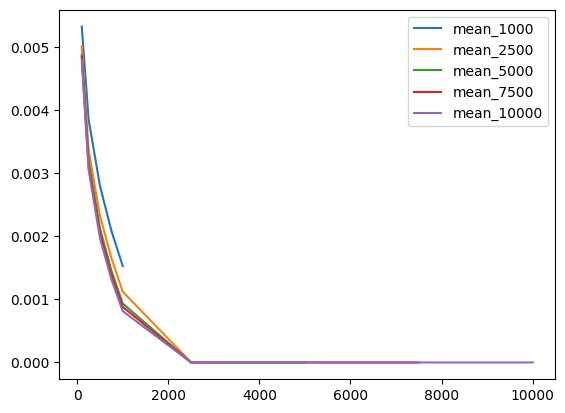

In [ ]:
for i in [1000, 2500, 5000, 7500, 10000]: 
    plt.plot(k_list, saved_svds[f"mse_{i}"], label = f"mean_{i}")
plt.legend()


In [ ]:
# Plot average reconstruction MSE by depth on a test set
test = data_gen.generate_data(101)
test = test.I.reshape(101, -1)
test_mean = test.mean(axis = 0)
test = test - test_mean
depth = 400
name = "v_10000"
V = saved_svds[name]
encoding_test = test @ V[:, :depth]
decoded = encoding_test @ V[:, :depth].T
# display an example reconstruction
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].imshow((test[10] + matrix_mean).reshape(64, 64).cpu().numpy())
ax[1].imshow((decoded[10] + matrix_mean).reshape(64, 64).cpu().numpy())
fig, ax = plt.subplots(1, 1, figsize = (10, 5))
# plot reconstruction error by depth: 
depths = [10, 50, 100, 200, 300, 400, 500, 1000, 2000]
mse = []
for depth in depths:
    encoding_test = test @ V[:, :depth]
    decoded = encoding_test @ V[:, :depth].T
    mse.append(((decoded - test) ** 2).mean().cpu().numpy())
ax.plot(depths, mse)

# Interim Conclusion

Without many hiccups, we were able to find that reconstruction performance seems to stabilise for around 7500-10000 datapoints. That's managable calculation for full svd, so no ssvd seemed to be needed. Let's skip that.

We choose to use the 10000-datapoint version for steps onwards. We can save it to OBJECT_PATH alongside the object it is computed on. 

Choices can be made regarding the effective rank we want to use. Let's now stick with 400. 

NOTE: for now I am going to jump back to investigate if switching to train the model to use only 5 steps rollout instead of 10 can reach similar performance with similar amount of data. 

- [x] DONE - looks good - a few more epochs but similar level of data-efficiency. 

NOTE: Better compression would still be possible with VAEs. I will quickly investigate that too. 

- [x] DONE: investigate VAEs for encoding

In [ ]:
from Network_models.VaeTrainer import VaeTrainer
from utils import force_remove_dir
obj_path_dict = {
    "cow": DATA_PATH + "/cow_mesh/cow.obj",
}
obj_index_dict = {
    "cow": None
}
cam_position = {
    "cow": 2.7,
}

obj_name = "cow"
obj_index = obj_index_dict.get(obj_name, None)
obj_path = obj_path_dict.get(obj_name, None)
cam_pos = cam_position.get(obj_name, None)
obj_name = obj_name + "_" + obj_index + ".obj" if obj_index is not None else obj_name + ".obj"

network_name = "simple_VAE"
task_name = "1.1"
re_train = 0
resolution_in = 64
resolution_out = resolution_in
latent_dimension = 256

config = {"model_specs": {
    "model_name": "RotationVAE",  # to be added (CustomRNN or FC_RNN)
    "model_path": "Network_models.RotationVAE",
    "model_params": {
        "input_resolution": resolution_in,
        "output_resolution": resolution_out,
        "latent_dimension": latent_dimension,
        "encoder": "simple", 
        "decoder": "FC",
        }, 
}, "model_id": network_name, "device": "cuda", "scheduler": False, # Uses the ReduceLROnPlateau scheduler
    "optimizer_specs": {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.001
    }
}, "reconstruction_loss": "MSE", "kl_divergence_loss": "Normal", "annealing": True, "annealing_function": "constant",
    "training_config": {
        "task_id": "1.1",
        "batch_size": 4096,
        "mini_batch_size":1024,
        "resolution": resolution_in,
        "cam_position": 2.7,#cam_pos,
        "object_path": obj_path,
        "use_AR": True, 
    }, 'save_path': MODEL_SAVE_PATH + f"/{network_name}_latent{latent_dimension}_res_in{resolution_in}_res_out"
                                        f"{resolution_out}_model/", 
    'log_path': LOG_PATH + f"/{network_name}_latent{latent_dimension}_res_in{resolution_in}_res_out{resolution_out}/",
    'check_path': MODEL_SAVE_PATH + f"/{network_name}_latent{latent_dimension}_res_in{resolution_in}_res_out"
                                        f"{resolution_out}_model_checkpoints/",
}
config['training_config']['data_save_path'] = (DATA_PATH + 
                                               f"/Data_{task_name}_res{config['training_config']['resolution']}_{obj_name[:-4]}_cam{config['training_config']['cam_position']}")

for path in [config['save_path'], config['log_path'], config['check_path'], config['training_config']['data_save_path']]:
    if not os.path.exists(path):
        os.makedirs(path)
    elif not re_train:
        print(f"Path already exists for {network_name} in task {task_name}. Assume the model is already trained.")
    else: # re_train
        force_remove_dir(path)
        os.makedirs(path)
print(config['save_path'])
trainer = VaeTrainer(config)
trainer.model.resolution_in = resolution_in
training_args = {
    "batch_size": 4096, 
    "mini_batch_size": 1024, 
    "epochs_to_calculate": 50,
    "loss": "MSE", 
    "epochs": 1000, 
    "save_interval": 100, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": config['training_config']['data_save_path'],
    "verbose": True,
    "replacement_tolerance": 0.5,
}
training_args['save_path'] = config["save_path"] + "model.pth"
training_args['data_loader_configs'] = {}
trainer.config['training_config'] = training_args
# print(f"tensorboard --logdir {config['log_path']}")
# trainer.train_unlimited(**training_args)

Path already exists for simple_VAE in task 1.1. Assume the model is already trained.
Path already exists for simple_VAE in task 1.1. Assume the model is already trained.
Path already exists for simple_VAE in task 1.1. Assume the model is already trained.
Path already exists for simple_VAE in task 1.1. Assume the model is already trained.
/home/timmy/nonnormal/dummy/mental-rotations/saved_models/simple_VAE_latent256_res_in64_res_out64_model/
trying to initialise VAE
no scheduler


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
        ^^^^^^^^^
AttributeError: 'NativePathHandler' object has no attribute '_evt'


trying to initialise VAE
no scheduler
trying to initialise VAE
no scheduler


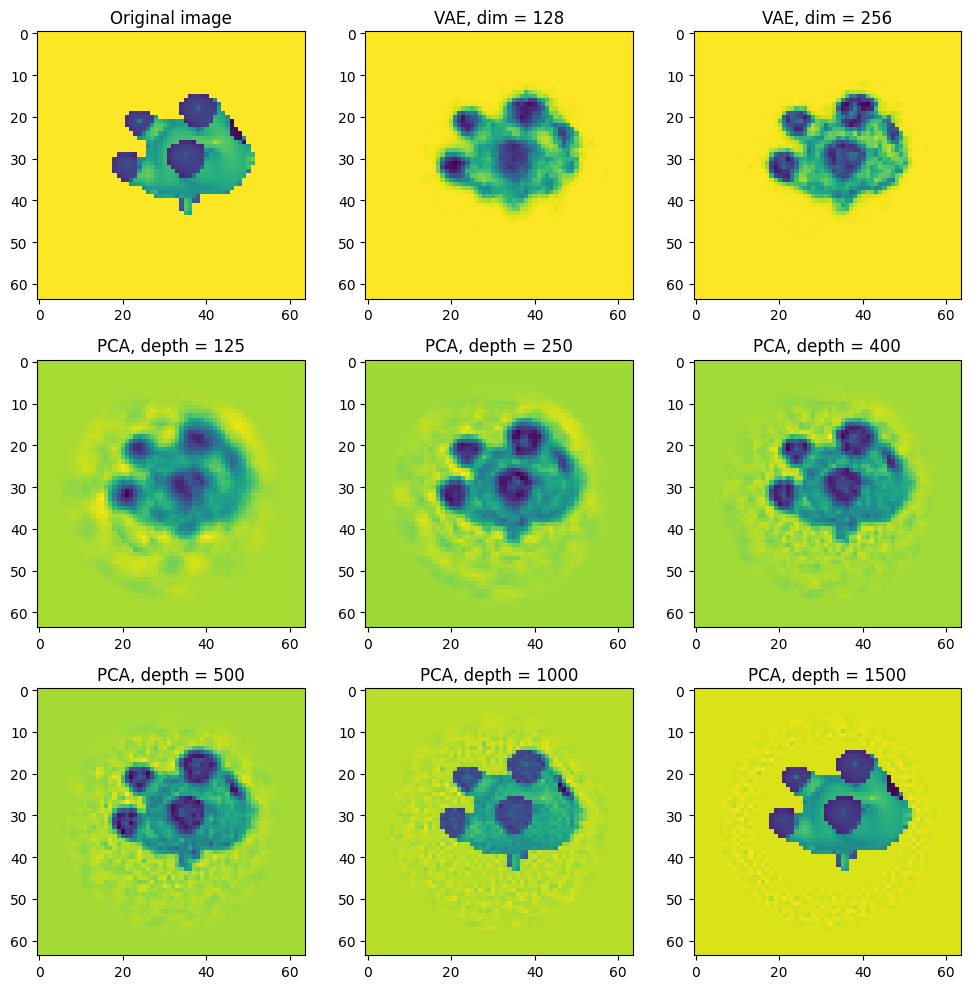

In [ ]:
config["model_specs"]["model_params"]["latent_dimension"] = 256
trainer_256 = VaeTrainer(config)
path = MODEL_SAVE_PATH + f"/simple_VAE_latent{256}_res_in64_res_out64_model_checkpoints/"
trainer_256.load_checkpoint(path + "checkpoint999.pth")
trainer_256.save_model(OBJECT_PATH + "/cow_mesh/256_latent_model.pth", 1)

config["model_specs"]["model_params"]["latent_dimension"] = 128
path = MODEL_SAVE_PATH + f"/simple_VAE_latent{128}_res_in64_res_out64_model_checkpoints/"
trainer_128 = VaeTrainer(config)
trainer_128.load_checkpoint(path + "checkpoint999.pth")
trainer_128.save_model(OBJECT_PATH + "/cow_mesh/128_latent_model.pth", 1)

# Let's check the reconstruction quality: 
trainer_256.data_gen = trainer_256.data_generator(custom_configs = {"target_seq_len": 1})
testimage = trainer_256.data_gen.generate_data(10)

saved_svds = torch.load(OBJECT_PATH + "/cow_mesh/svd_data.pth")
name = "v_10000"
V = saved_svds[name]
depths = [125, 250, 400, 500, 1000, 1500]

mse = []

fig, ax = plt.subplots(3, 3, figsize = (10, 10))
ax[0, 0].imshow(testimage.data[0].cpu().numpy().reshape(64, 64))
# add title
ax[0, 0].set_title("Original image")

_, mu, log_var = trainer_128.model(testimage.data)
x_hat = trainer_128.model.decode(mu)[:, ...]
ax[0, 1].imshow(x_hat[0].detach().cpu().numpy().reshape(64, 64))
ax[0, 1].set_title("VAE, dim = 128")
mse.append(((x_hat - testimage.data) ** 2).mean(dim=[1,2,3]).cpu().detach().numpy())

_, mu, log_var = trainer_256.model(testimage.data)
x_hat = trainer_256.model.decode(mu)[:, ...]
ax[0, 2].imshow(x_hat[0].detach().cpu().numpy().reshape(64, 64))
ax[0, 2].set_title("VAE, dim = 256")
mse.append(((x_hat - testimage.data) ** 2).mean(dim=[1,2,3]).cpu().detach().numpy())

test_for_PCA = testimage.data.flatten(1) - saved_svds["mean_10000"]
for i, depth in enumerate(depths): 
    j = i + 2
    encoding = test_for_PCA @ V[:, :depth]
    decoded = encoding @ V[:, :depth].T + saved_svds["mean_10000"]
    ax[(j + 1) // 3, (j + 1) % 3].imshow(decoded[0].cpu().numpy().reshape(64, 64))
    ax[(j + 1) // 3, (j + 1) % 3].set_title(f"PCA, depth = {depth}")
    mse.append(((decoded.reshape(testimage.data.shape) - testimage.data) ** 2).mean(dim=[1,2,3]).cpu().detach().numpy())
plt.tight_layout()

# in a separate plot, plot box plots of MSE differences: 

/tmp/ipykernel_149547/2535872245.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(mse, labels = ["VAE128", "VAE256"] + [f"PCA{depth}" for depth in depths])


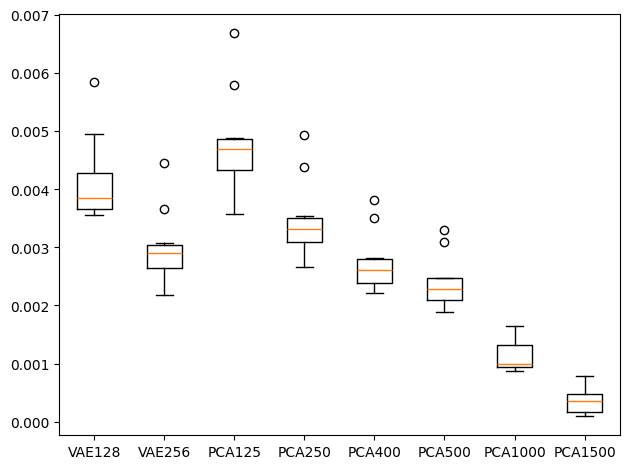

In [ ]:
plt.boxplot(mse, labels = ["VAE128", "VAE256"] + [f"PCA{depth}" for depth in depths])
plt.tight_layout()

In [ ]:
svd_data_10000 = {
    "V": saved_svds["v_10000"],
    "mean": saved_svds["mean_10000"],
    "s": saved_svds["s_10000"],
}
torch.save(svd_data_10000, OBJECT_PATH + "/cow_mesh/svd_data_10000.pth")

# Train with Encodings!

In [29]:
# HIDE CODE
# use a placeholder trainer object to generate sample data 
tau = 100
dt = 1
# loss = "Predictor-Geodesic"
encoding_name = "VAE_256"
encoding_net = encoding_name[:3]
encoding_dim = int(encoding_name[4:])
if encoding_net == "PCA":
    encoder_specs = {
        "model_name": "PCAEncoder",
        "model_path": "Network_models.ForwardModels",
        "model_params": {
            "input_size": 64 * 64,
            "PC_num": 400,
            "stored_params_path": OBJECT_PATH + "/cow_mesh/svd_data_10000.pth",
        }
    }
else: 
    encoder_specs = {
        "model_name": "VAEEncoder",
        "model_path": "Network_models.ForwardModels",
        "model_params": {
            "stored_model_path": OBJECT_PATH + f"/cow_mesh/{encoding_dim}_latent_model.pth",
        }
    }

decoder_specs = None
additional_name = "input_time_10_silence_5_train_10_8_encoding_" + encoding_name
batch_size = 8192
mini_batch_size = 2048
predictor_specs = {
    "model_name": "FastRecurrence", 
    "model_path": "Network_models.ForwardModels", 
    "model_params": {
        "input_size": 200, 
        "output_size": encoding_dim, 
        "hidden_sizes": [256],
        "input_presentation_time": 10,
        "silence_time": 5,
        "RNN_type": "GRU", 
        "flatten_readout": False,
        "RNN_params": {
            "hidden_size": 200, 
            "num_layers": 1, 
            "batch_first": True, 
        },
        "linear_params": {
            "hidden_sizes": [
                32,
            ],
        },
    },
    "frozen": False, 
}
dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.008,
    }
}

data_loader_configs = {
    "batch_size": 1024,
    "encoder_specs": encoder_specs,
    "target_seq_len": 5,
}

loss = "Predictor-MSEGradual"
if loss[-7:] == "Gradual": 
    dynamics_model_specs['model_params']['stepwise'] = True
    assert predictor_specs['model_params']['silence_time'] > 1
    additional_name = additional_name + "_stepwise"
    predictor_specs['model_params']['stepwise'] = True
    # data_loader_configs["target_seq_len"] = predictor_specs['model_params']['silence_time']
    # data_loader_configs["target_seq_len"] = dynamics_model_specs['model_params']['action_period']

model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "encoder_specs": encoder_specs,
    "decoder_specs": decoder_specs,
    "predictor_specs": predictor_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

import time
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 8,
    "loss": loss, 
    "epochs": 500, 
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss[-7:] == "Gradual" else ""}_encoding_" + encoding_name + "/",
    "verbose": True,
    "replacement_tolerance": 0.5,
}

trainer = FMTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
print(data_loader_configs)
trainer.config['training_config'] = training_args
trainer.data_gen = trainer.data_generator(lean=False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})

An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
        ^^^^^^^^^
AttributeError: 'NativePathHandler' object has no attribute '_evt'


{'batch_size': 1024, 'encoder_specs': {'model_name': 'VAEEncoder', 'model_path': 'Network_models.ForwardModels', 'model_params': {'stored_model_path': '/home/timmy/nonnormal/dummy/mental-rotations/data/cow_mesh/256_latent_model.pth'}}, 'target_seq_len': 5}


In [30]:
print(f"tensorboard --logdir {config['log_path']}")
trainer.train_fm(**training_args)

An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
        ^^^^^^^^^
AttributeError: 'NativePathHandler' object has no attribute '_evt'


tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_10_silence_5_train_10_8_encoding_VAE_256_stepwise//
predictor is now unfrozen.
Loading train_0.pth
Loading val_0.pth
Epoch 0, learning rate: 0.008
Epoch 0, training loss: 58.254173278808594, validation loss: 47.9884033203125
Epoch 1, training loss: 41.35090637207031, validation loss: 33.700775146484375
Epoch 2, training loss: 32.321632385253906, validation loss: 30.250940322875977
Epoch 3, training loss: 30.188148498535156, validation loss: 29.46975326538086
Epoch 4, training loss: 29.644187927246094, validation loss: 29.10829734802246
Epoch 5, training loss: 29.234888076782227, validation loss: 28.773727416992188
Epoch 6, training loss: 28.9451904296875, validation loss: 28.579227447509766
Epoch 7, training loss: 28.778186798095703, validation loss: 28.46825408935547
Epoch 8, training loss: 28.695201873779297, validation loss: 28.398605346679

KeyboardInterrupt: 

Generating 1 samples
Output acceleration


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
        ^^^^^^^^^
AttributeError: 'NativePathHandler' object has no attribute '_evt'


Time for forward network dynamics : 0.4046156406402588
Time for rendering the dataset: 0.11374163627624512
MSE:  3.2844193


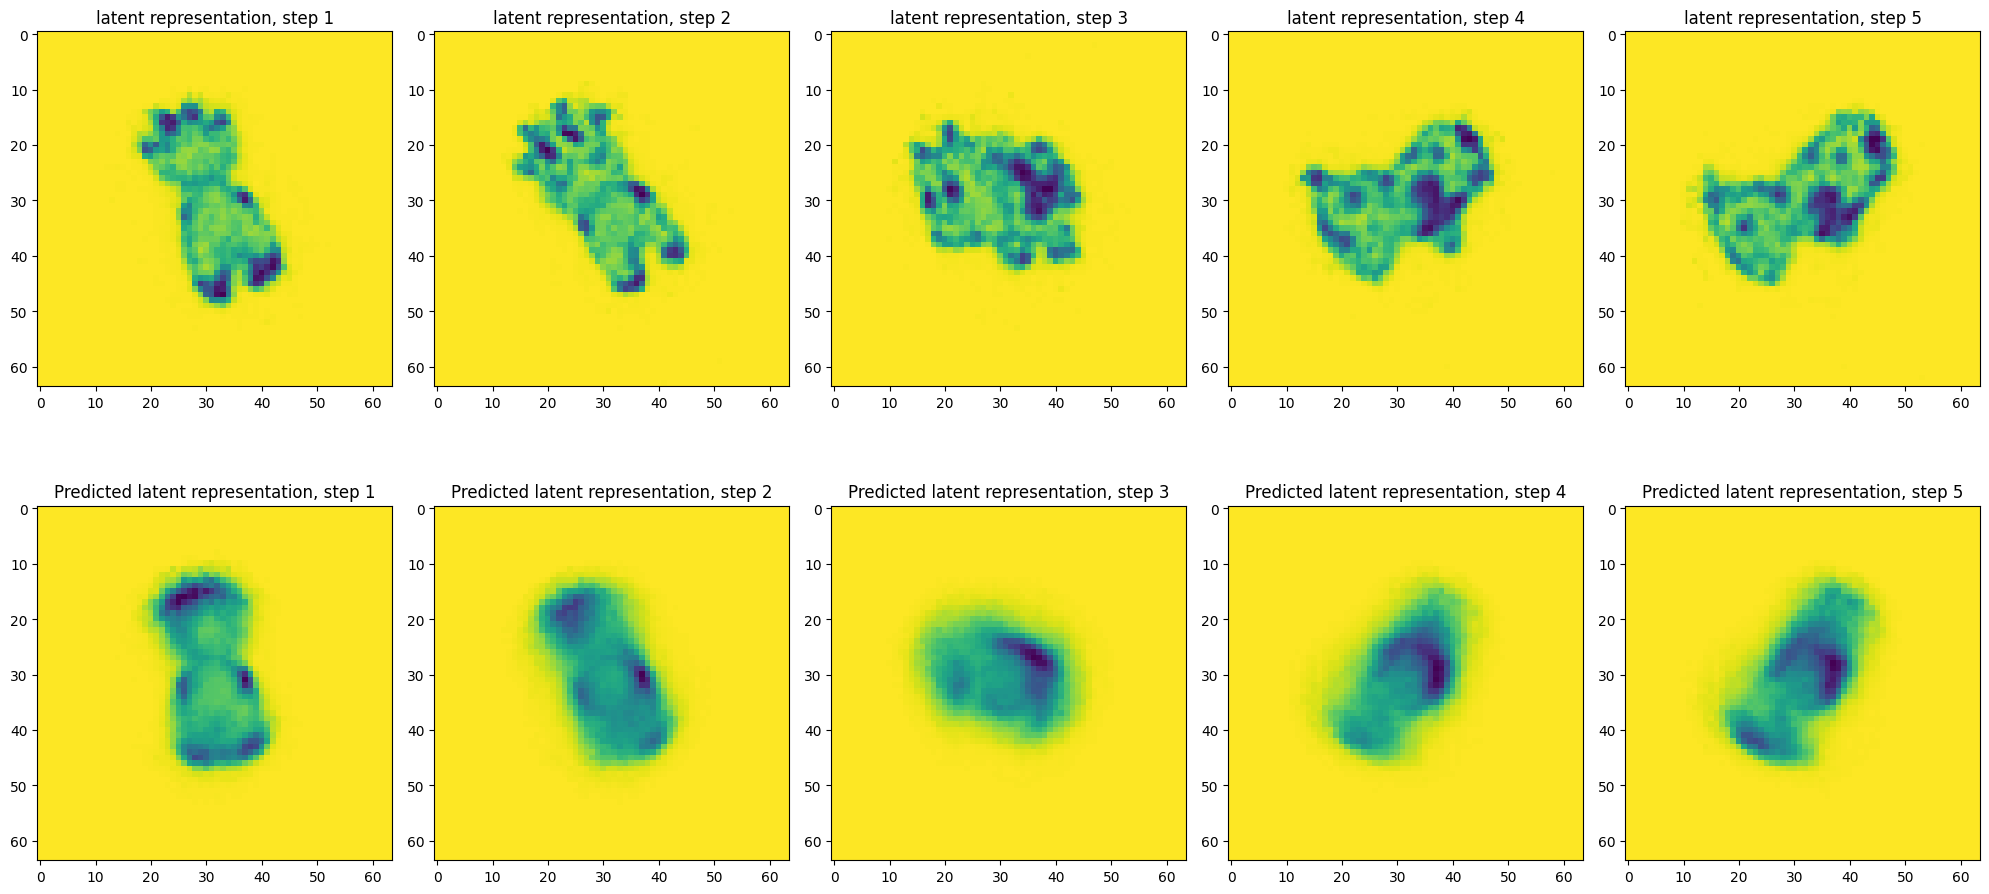

In [35]:
# Check how the model is doing on a test sample: 
test = trainer.data_gen.generate_data(1)
trainer.model.eval()
pred, enc, dec = trainer.model([test.z0, test.I, test.q])
print("MSE: ", ((pred - enc) ** 2).mean().cpu().detach().numpy())
fig, axs = plt.subplots(2, 5, figsize = (20, 10))
enc_graphs = trainer.data_gen.encoding_model.decode(enc * (trainer.whitening_vector ** -1 if trainer.whitening_vector is not None else 1))
pred_graphs = trainer.data_gen.encoding_model.decode(pred * (trainer.whitening_vector ** -1 if trainer.whitening_vector is not None else 1))
for i in range(5):
    axs[0, i].imshow(enc_graphs[0, i].cpu().detach().numpy().reshape(64, 64))
    axs[0, i].set_title(f"latent representation, step {i + 1}")
    axs[1, i].imshow(pred_graphs[0, i].cpu().detach().numpy().reshape(64, 64))
    axs[1, i].set_title(f"Predicted latent representation, step {i + 1}")
fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(2, 5, figsize = (20, 10))
enc_graphs = trainer.data_gen.encoding_model.decode(enc * (trainer.whitening_vector ** -1))
pred_graphs = trainer.data_gen.encoding_model.decode(pred  * (trainer.whitening_vector ** -1))
for i in range(5):
    axs[0, i].imshow(enc_graphs[0, i].cpu().numpy().reshape(64, 64))
    axs[1, i].imshow(pred_graphs[0, i].cpu().detach().numpy().reshape(64, 64))

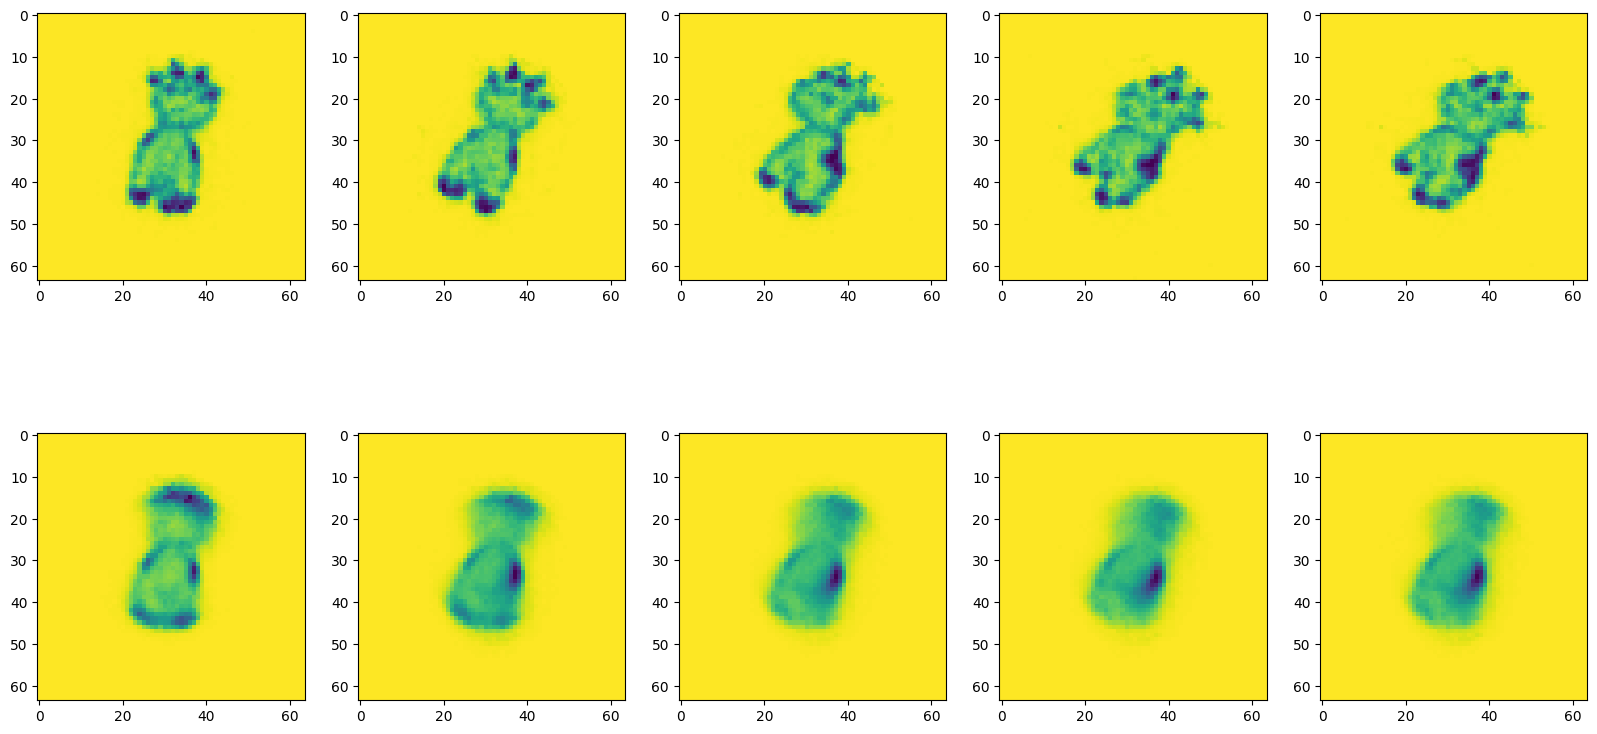

In [13]:
fig, axs = plt.subplots(2, 5, figsize = (20, 10))
enc_graphs = trainer.data_gen.encoding_model.decode(enc)
pred_graphs = trainer.data_gen.encoding_model.decode(pred)
for i in range(5):
    axs[0, i].imshow(enc_graphs[0, i].cpu().detach().numpy().reshape(64, 64))
    axs[1, i].imshow(pred_graphs[0, i].cpu().detach().numpy().reshape(64, 64))

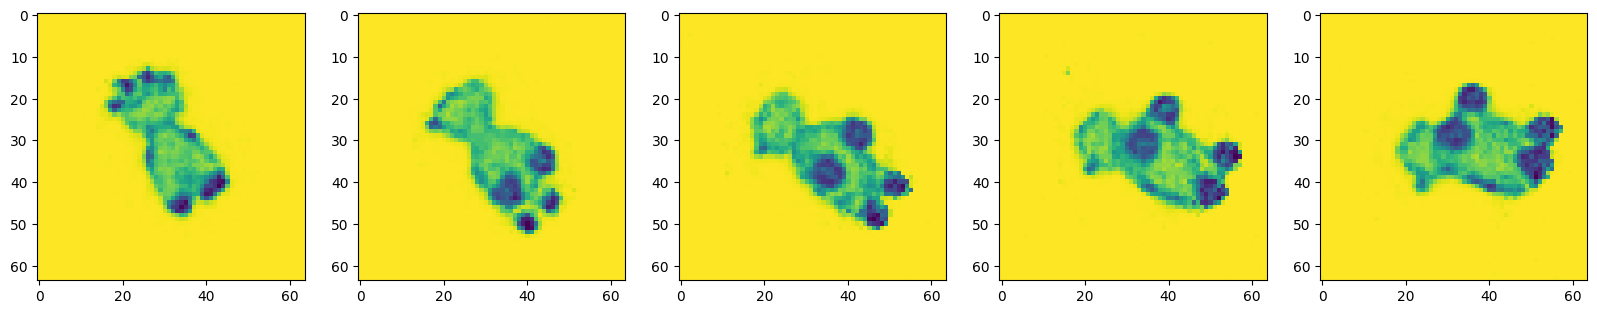

In [18]:
b = trainer.data_gen.encoding_model.decode(data.I)
fig, axs = plt.subplots(1, 5, figsize = (20, 5))
for i in range(5):
    axs[i].imshow(b[0, i].cpu().detach().numpy().reshape(64, 64))

# Shift gears to cubes (bye now, cows)

torch.Size([3, 3, 8, 3])


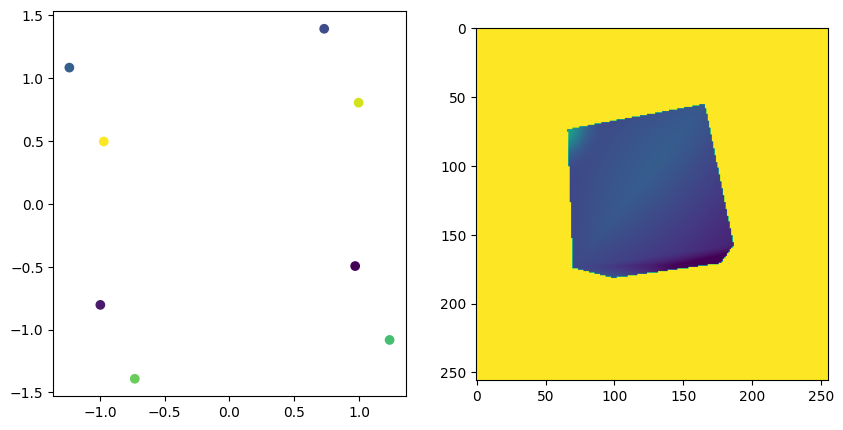

In [180]:
resolution = 256
cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = "full")
quat = torch.randn(3, 3, 4) 
returned = cube.quat2verts(quat/norm, "full")
# plt.imshow(returned.cpu().numpy().reshape(16, 16))
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
print(returned.shape)
axs[0].scatter(-returned[0, 0, :, 0].cpu().numpy(), returned[0, 0, :, 1].cpu().numpy(), c = returned[0, 0, :, 2].cpu().numpy())
image = cube.render_cube()
axs[1].imshow(image[0,0].cpu().numpy().reshape(resolution, resolution))
torch.save(cube, OBJECT_PATH + "/cube_mesh/cube_mesh.pth")

In [2]:
from SimulateDatasets.CubeMesh import CubeMesh
tau = 100
dt = 1
resolution = 256
mode = "full"
steps = 5
cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
torch.save(cube, cube_path)
decoder_specs = None
additional_name = f"input_time_1_silence_{steps}_train_10_8_cube" + (("_" + mode) if mode != "" else "")
batch_size = 8192
mini_batch_size = 2048
predictor_specs = {
    "model_name": "FastRecurrence", 
    "model_path": "Network_models.ForwardModels", 
    "model_params": {
        "input_size": 200, 
        "output_size": 16 if mode == "camera_simple" else 24, 
        "hidden_sizes": [256],
        "input_presentation_time": 1,
        "silence_time": steps,
        "RNN_type": "GRU", 
        "flatten_readout": False,
        "RNN_params": {
            "hidden_size": 200, 
            "num_layers": 1, 
            "batch_first": True, 
        },
        "linear_params": {
            "hidden_sizes": [
                32,
            ],
        },
    },
    "frozen": False, 
}
dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.008,
    }
}

data_loader_configs = {
    "batch_size": 8192,
    "encoder_specs": None,
    "target_seq_len": 5,
    "object_path": cube_path,
}

loss = "Predictor-MSEGradual"
if loss[-7:] == "Gradual": 
    dynamics_model_specs['model_params']['stepwise'] = True
    # assert predictor_specs['model_params']['silence_time'] > 1
    additional_name = additional_name + "_stepwise"
    predictor_specs['model_params']['stepwise'] = True
    # data_loader_configs["target_seq_len"] = predictor_specs['model_params']['silence_time']
    # data_loader_configs["target_seq_len"] = dynamics_model_specs['model_params']['action_period']

model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "encoder_specs": None,
    "decoder_specs": decoder_specs,
    "predictor_specs": predictor_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

import time
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 8,
    "loss": loss, 
    "epochs": 1000, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss[-7:] == "Gradual" else ""}" + "_cube" + (("_" + mode) if mode != "" else "") +  "/",
    "verbose": False,
    "replacement_tolerance": 0.5,
}

trainer = FMTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
print(data_loader_configs)
trainer.config['training_config'] = training_args
trainer.data_gen = trainer.data_generator(lean=False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})

{'batch_size': 8192, 'encoder_specs': None, 'target_seq_len': 5, 'object_path': '/home/timmy/nonnormal/dummy/mental-rotations/data/cube_mesh/cube_mesh_full.pth'}


In [11]:
trainer.data_gen.recycle_data(data_path = DATA_PATH + "/forward_model_data_stepwise_cube_full", save_path = training_args["data_save_path"])

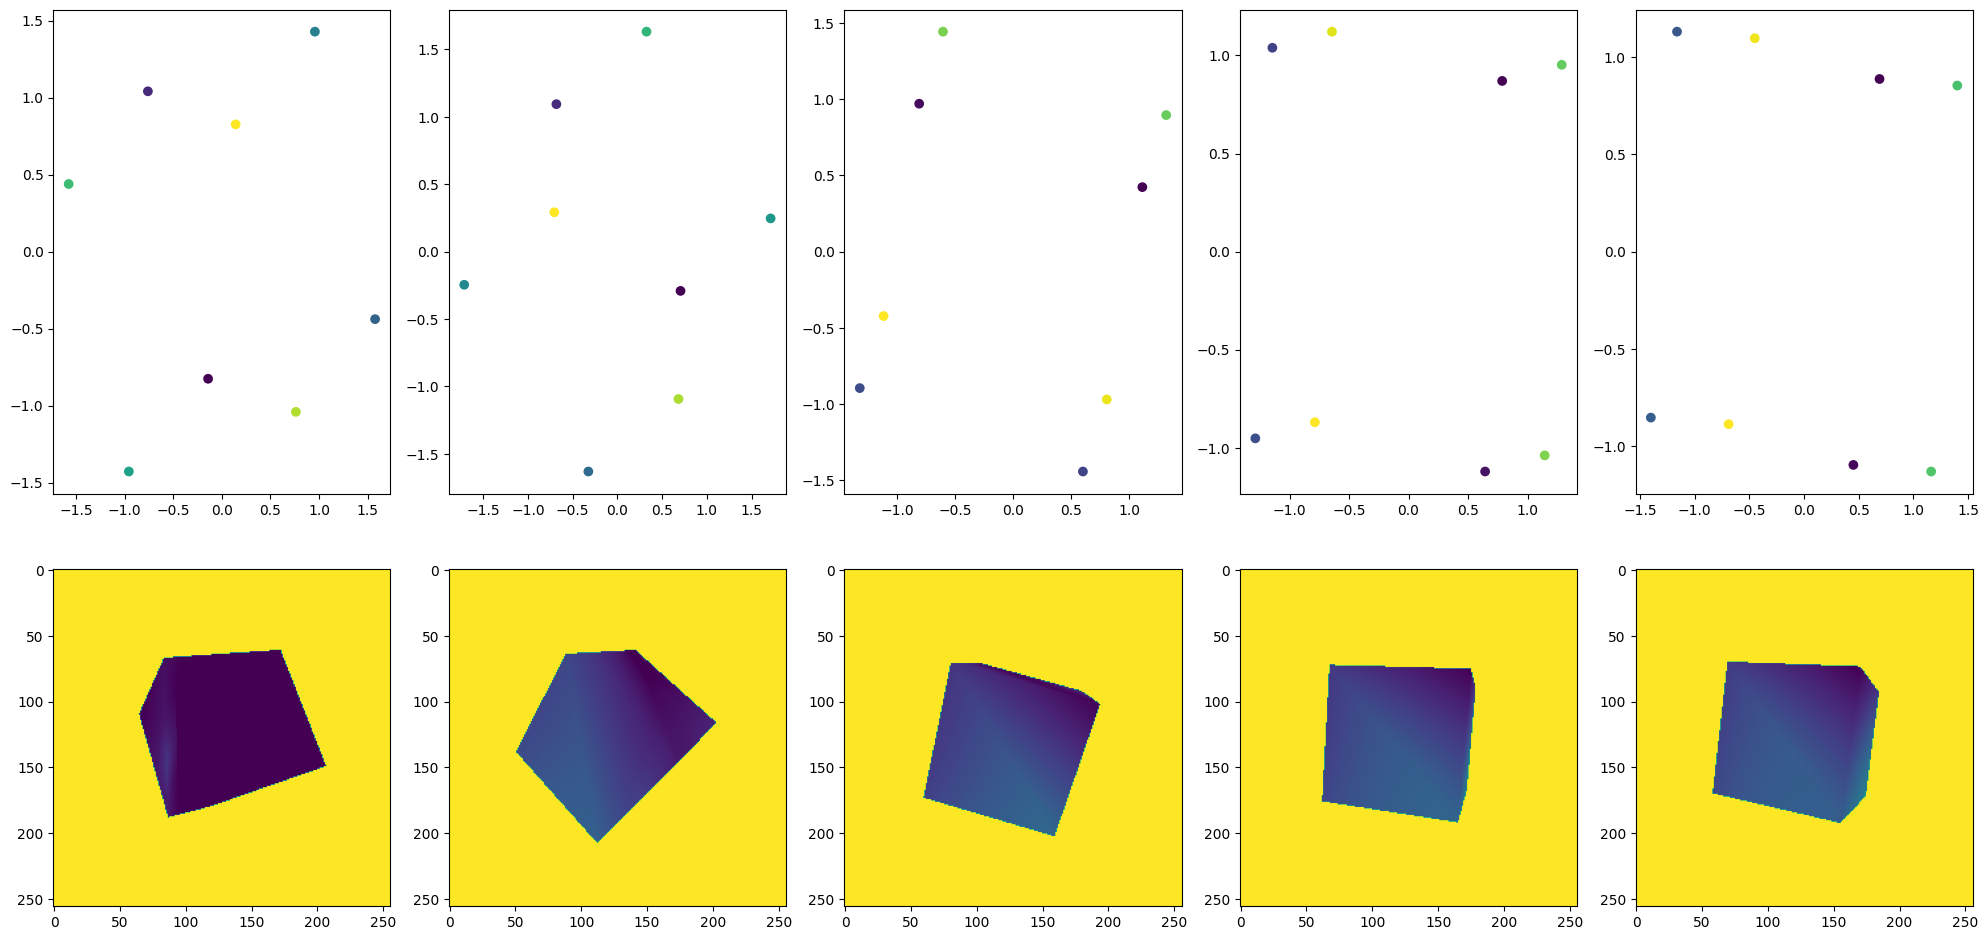

In [25]:
data = torch.load(training_args["data_save_path"] + "/train_0.pth")
data.I.shape
i = data.I.view(8192, 5, 8, 3)
fig, axs = plt.subplots(2, 5, figsize = (20, 10))
for j in range(5):
    axs[0, j].scatter(-i[0, j, :, 0].cpu().numpy(), i[0, j, :, 1].cpu().numpy(), c = i[0, j, :, 2].cpu().numpy())
    image = cube.render_cube(cube = i[0, j])
    axs[1, j].imshow(image[0].cpu().numpy().reshape(resolution, resolution))
fig.tight_layout()

In [9]:
for s in range(5):
    step = s + 1
    additional_name = f"input_time_1_silence_{step}_train_10_8_cube" + (("_" + mode) if mode != "" else "")
    model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"
    config['predictor_specs']['model_params']['silence_time'] = step
    config['log_path'] = LOG_PATH + model_path + "/"
    config['save_path'] = MODEL_SAVE_PATH + model_path + "/"
    config['check_path'] = MODEL_SAVE_PATH + model_path + "/"
    training_args['save_path'] = config["save_path"] + "model.pth"
    for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
        os.makedirs(path, exist_ok = True)
    trainer = FMTrainer(config)
    # Let's just train! what could go wrong?
    print(f"tensorboard --logdir {config['log_path']}")
    trainer.train_fm(**training_args)

tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_1_train_10_8_cube_full//
predictor is now unfrozen.
Loading train_0.pth
8192
0
Loading val_0.pth
1024
0
Epoch 0, learning rate: 0.008
Loading train_1.pth
8192
0
Replaced 50.62438201904297% of the data, new data size: 8192, original size: 8192
Loading train_2.pth
8192
0
Replaced 79.5558090209961% of the data, new data size: 8192, original size: 8192
Loading train_3.pth
8192
0
Replaced 98.07542419433594% of the data, new data size: 8192, original size: 8192
Loading train_4.pth
8192
0
Replaced 71.00155639648438% of the data, new data size: 8192, original size: 8192
Loading train_5.pth
8192
0
Replaced 61.33441925048828% of the data, new data size: 8192, original size: 8192
Loading train_6.pth
8192
0
Replaced 71.03572082519531% of the data, new data size: 8192, original size: 8192
Epoch 100, learning rate: 0.008
Loading train_7.pth
8192
0

Generating 1 samples


/home/timmy/nonnormal/dummy/mental-rotations/Network_models/DynamicalNetwork.py:37: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  y = x[:, i - 1, :] + (-x[:, i - 1, :] + (W @ x[:, i - 1, :].T).T) / tau * dt


Output acceleration
Time for forward network dynamics : 1.0114398002624512
Time for rendering the dataset: 0.0008425712585449219
torch.Size([1, 5, 8, 3])
torch.Size([1, 5, 8, 3])


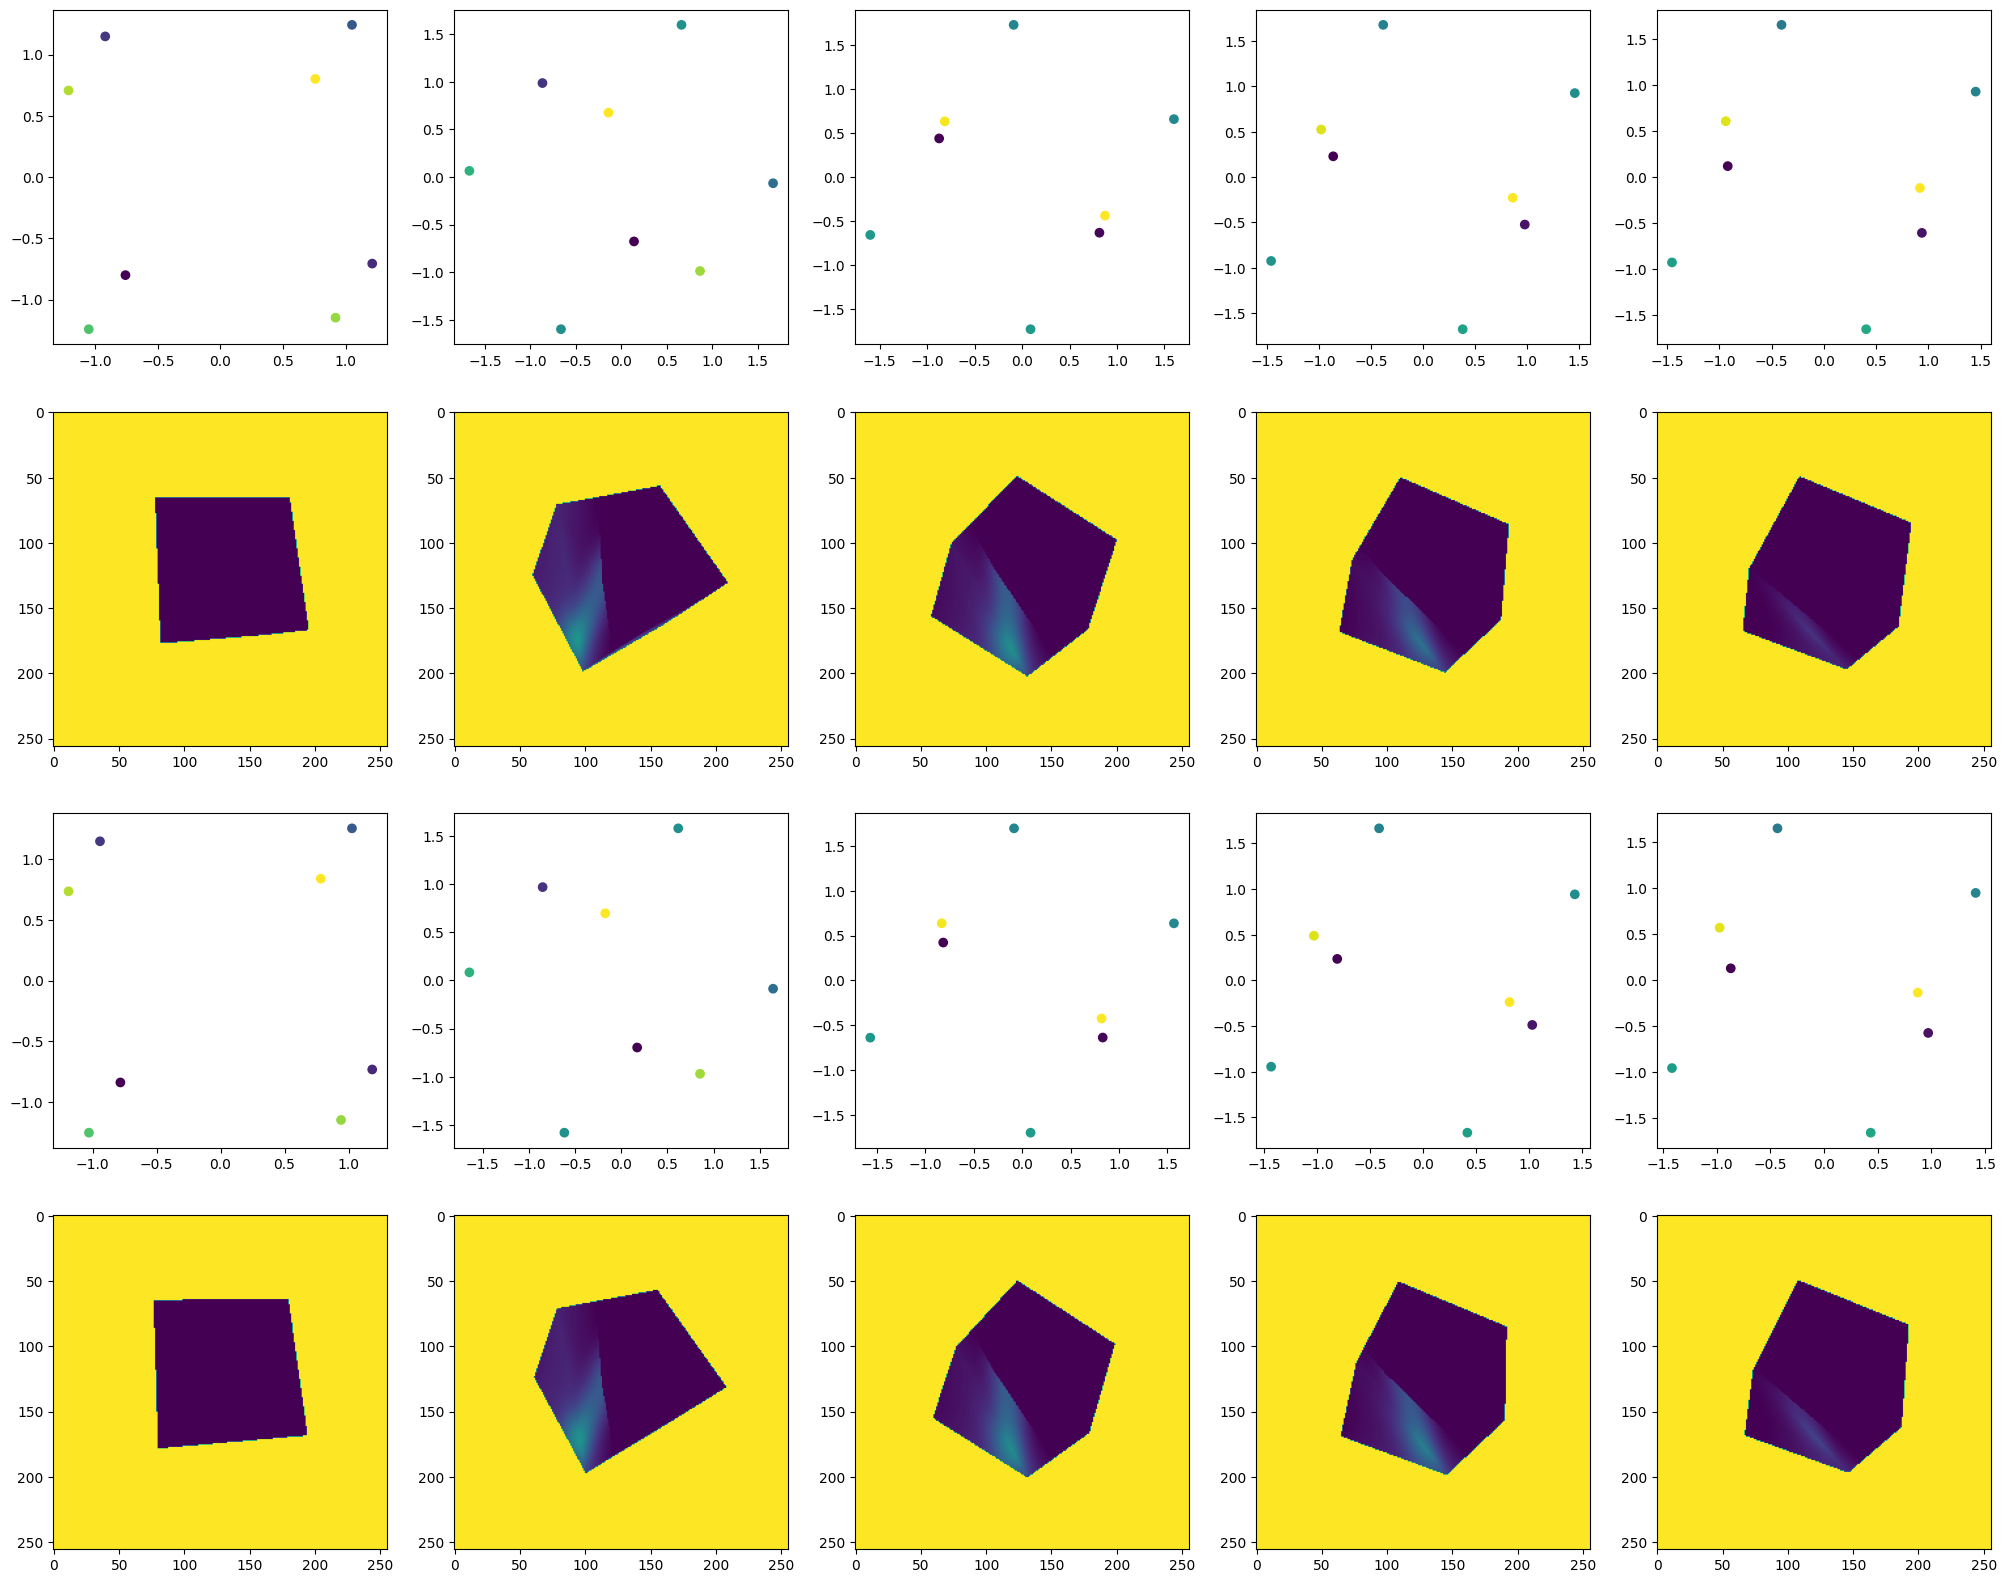

In [4]:
# Let's see how the model is doing: 
trainer.data_gen = trainer.data_generator(lean = False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})
test = trainer.data_gen.generate_data(1)
step = 5
model_path = MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEFastRecurrence_dynamics_0.07input_time_1_silence_{step}_train_10_8_cube_full/"
trainer.load_model(training_args['save_path'], full = 1)
trainer.model.eval()
steps = config["predictor_specs"]["model_params"]["silence_time"]
pred, enc, dec = trainer.model([test.z0, test.I, test.q])
pred = pred.view(-1, 5, 8, 3)
enc = enc.view(-1, 5, 8, 3)
# print("MSE: ", ((pred - enc) ** 2).mean().cpu().detach().numpy())
fig, axs = plt.subplots(4, 5, figsize = (25, 20))
plotted = 0
print(enc.shape)
print(pred.shape)
steps = torch.linspace(-1, 4, step + 1)[1:]
for i in range(5):
    axs[0, i].scatter(-enc[0, i, :, 0].cpu().numpy(), enc[0, i, :, 1].cpu().numpy(), c = enc[0, i, :, 2].cpu().numpy())
    axs[1, i].imshow(cube.render_cube(cube = enc[0, i])[0].cpu().numpy().reshape(resolution, resolution))
    if i in steps:
        axs[2, i].scatter(-pred[0, plotted, :, 0].detach().cpu().numpy(), pred[0, plotted, :, 1].detach().cpu().numpy(), c = pred[0, plotted, :, 2].detach().cpu().numpy())
        axs[3, i].imshow(cube.render_cube(cube = pred[0, plotted])[0].cpu().detach().numpy().reshape(resolution, resolution))
        plotted += 1

Generating 1000 samples
Output acceleration
Time for forward network dynamics : 2.7277753353118896
Time for rendering the dataset: 0.004034280776977539
shape of pred: torch.Size([1000, 1, 8, 2])
shape of pred: torch.Size([1000, 2, 8, 2])
shape of pred: torch.Size([1000, 3, 8, 2])
shape of pred: torch.Size([1000, 4, 8, 2])
shape of pred: torch.Size([1000, 5, 8, 2])
Generating 1000 samples
Output acceleration
Time for forward network dynamics : 4.61303186416626
Time for rendering the dataset: 0.002158641815185547


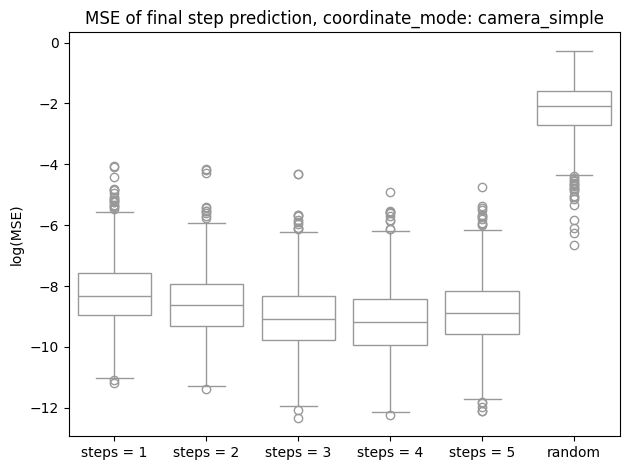

In [5]:
# Compare the differences between test set performance over different stepsize for rollout. 
#   in the future we can make rollout a choice - a separate node to determine rollout stepsize
#   for now and near future, we can stick with fixed unit rollout size and make RT fully dependent on the controller. 
import seaborn as sns
mode = "camera_simple"
if mode == "full" or mode == "binary":
    output_size = 3
else: 
    output_size = 2
training_args['data_loader_configs']['object_path'] = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
trainer.data_gen = trainer.data_generator(lean = False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})
test = trainer.data_gen.generate_data(1000)
candidate_steps = [1, 2, 3, 4, 5]
mse = []
for steps in candidate_steps: 
    stepped_model_additional_name = f"input_time_1_silence_{steps}_train_10_8_cube" + (("_" + mode) if mode != "" else "")

    trainer.load_model(MODEL_SAVE_PATH + f"/forward_model_{loss}/FastRecurrence_dynamics_0.07{stepped_model_additional_name}{"_stepwise" if mode == "full" else ""}/model.pth", 1)
    trainer.model.eval()
    pred, enc, dec = trainer.model([test.z0, test.I, test.q])
    pred = pred.view(-1, steps, 8, output_size)
    enc = enc.view(-1, 5, 8, output_size)
    print(f"shape of pred: {pred.shape}")
    # append a np array of final MSE over the batch here: 
    mse.append(torch.log((pred[:, -1] - enc[:, -1]) ** 2).mean(dim = [1, 2]).cpu().detach().numpy())

rand = trainer.data_gen.generate_data(1000)
mse.append(torch.log((test.I[:, -1] - rand.I[:, -1]) ** 2).mean(dim = [1]).cpu().detach().numpy())
# Plot boxplot of the results
transparent_pallette = [(1, 1, 1, 0) for _ in range(len(candidate_steps) + 1)]
sns.set_palette(transparent_pallette)
sns.boxplot(mse)
plt.xticks(range(len(candidate_steps)+ 1), [*[f"steps = {steps}" for steps in candidate_steps], "random"])
plt.ylabel("log(MSE)")
plt.title("MSE of final step prediction, coordinate_mode: " + mode)
plt.tight_layout()
plt.savefig(FIG_PATH + f"/summary_internal_model/stepsize_mse_cube_{mode}.png")

In [2]:
from SimulateDatasets.CubeMesh import CubeMesh
tau = 100
dt = 1
resolution = 256
mode = "full"
cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
torch.save(cube, cube_path)
decoder_specs = None
additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "")
batch_size = 8192
mini_batch_size = 2048
predictor_specs = {
    "model_name": "FFModel", 
    "model_path": "Network_models.ForwardModels", 
    "model_params": {
        "input_size": 200, 
        "output_size": 16 if mode == "camera_simple" else 24, 
        "hidden_sizes": [256, 64],
        "activation": "ReLU",
    },
    "frozen": False, 
}
dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.008,
    }
}

data_loader_configs = {
    "batch_size": 8192,
    "encoder_specs": None,
    "target_seq_len": 5,
    "object_path": cube_path,
}

loss = "Predictor-MSEGradual"
if loss[-7:] == "Gradual": 
    dynamics_model_specs['model_params']['stepwise'] = True
    additional_name = additional_name + "_stepwise"
    predictor_specs['model_params']['stepwise'] = True

model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "encoder_specs": None,
    "decoder_specs": decoder_specs,
    "predictor_specs": predictor_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

import time
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 8,
    "loss": loss, 
    "epochs": 1000, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data{"_stepwise" if loss[-7:] == "Gradual" else ""}" + "_cube" + (("_" + mode) if mode != "" else "") +  "/",
    "verbose": False,
    "replacement_tolerance": 0.5,
}

trainer = FMTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
print(data_loader_configs)

{'batch_size': 8192, 'encoder_specs': None, 'target_seq_len': 5, 'object_path': '/home/timmy/nonnormal/dummy/mental-rotations/data/cube_mesh/cube_mesh_camera_simple.pth'}


Generating 1 samples
Output acceleration
Time for forward network dynamics : 0.24870705604553223
Time for rendering the dataset: 0.0022263526916503906
torch.Size([1, 5, 8, 2])
torch.Size([1, 1, 8, 2])


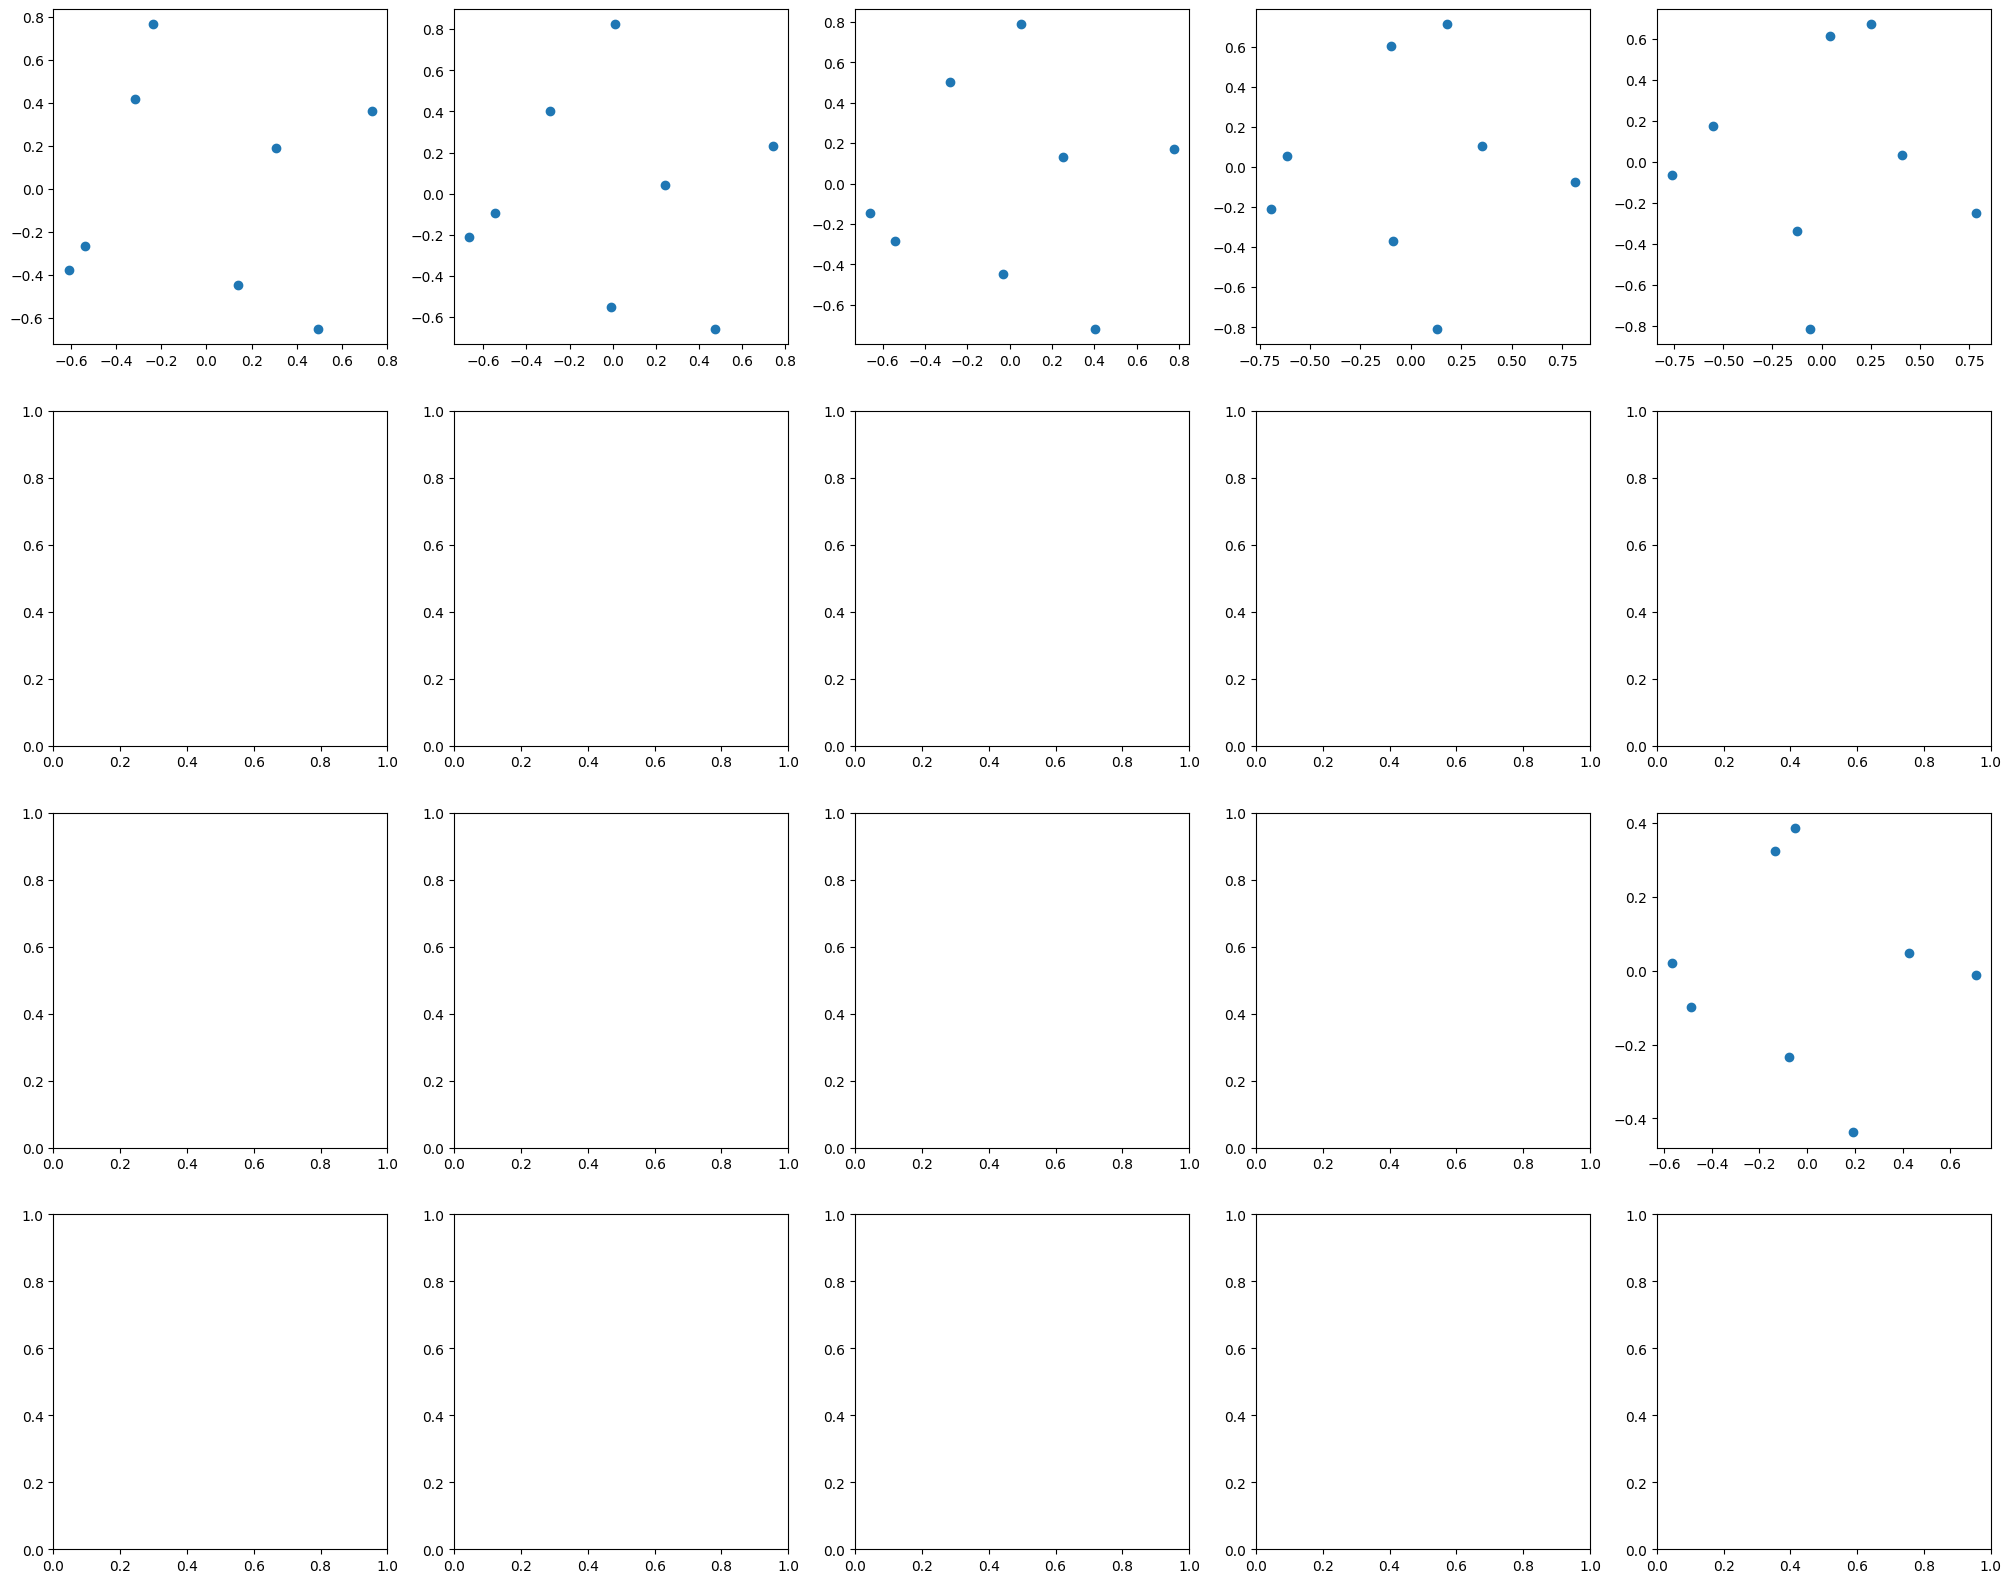

In [17]:
# Let's see how the model is doing: 
mode = "camera_simple"
trainer.data_gen = trainer.data_generator(lean = False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})
test = trainer.data_gen.generate_data(1)
trainer.load_model(training_args['save_path'], full = 1)
trainer.model.eval()
step = 1
pred, enc, dec = trainer.model([test.z0, test.I, test.q])
pred = pred.view(-1, step, 8, 2)
enc = enc.view(-1, 5, 8, 2)
fig, axs = plt.subplots(4, 5, figsize = (25, 20))
plotted = 0
print(enc.shape)
print(pred.shape)
steps = torch.linspace(-1, 4, step + 1)[1:]
for i in range(5):
    if mode != "camera_simple":
        axs[0, i].scatter(-enc[0, i, :, 0].cpu().numpy(), enc[0, i, :, 1].cpu().numpy(), c = enc[0, i, :, 2].cpu().numpy())
    else: 
        axs[0, i].scatter(-enc[0, i, :, 0].cpu().numpy(), enc[0, i, :, 1].cpu().numpy())
    # axs[1, i].imshow(cube.render_cube(cube = enc[0, i])[0].cpu().numpy().reshape(resolution, resolution))
    if i in steps:
        if mode != "camera_simple":
            axs[2, i].scatter(-pred[0, plotted, :, 0].detach().cpu().numpy(), pred[0, plotted, :, 1].detach().cpu().numpy(), c = pred[0, plotted, :, 2].detach().cpu().numpy())
        else: 
            axs[2, i].scatter(-pred[0, plotted, :, 0].detach().cpu().numpy(), pred[0, plotted, :, 1].detach().cpu().numpy())
        # axs[3, i].imshow(cube.render_cube(cube = pred[0, plotted])[0].cpu().numpy().reshape(resolution, resolution))
        plotted += 1

In [9]:
candidate_hidden2 = [32, 64, 128]
for hidden2 in candidate_hidden2:
    additional_name = f"Linear_256_{hidden2}_cube" + (("_" + mode) if mode != "" else "")
    model_path = f"/forward_model_{loss}/{predictor_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"
    config['predictor_specs']['model_params']['hidden_sizes'][1] = hidden2
    config['log_path'] = LOG_PATH + model_path + "/"
    config['save_path'] = MODEL_SAVE_PATH + model_path + "/"
    config['check_path'] = MODEL_SAVE_PATH + model_path + "/"
    training_args['save_path'] = config["save_path"] + "model.pth"
    for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
        os.makedirs(path, exist_ok = True)
    trainer = FMTrainer(config)
    # Let's just train! tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-MSEGradual/FFModel_dynamics_0.07Linear_cube_camera_simple_stepwise//what could go wrong?
    print(f"tensorboard --logdir {config['log_path']}")
    # trainer.train_fm(**training_args)

tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-MSEGradual/FFModel_dynamics_0.07Linear_256_32_cube_camera_simple//
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-MSEGradual/FFModel_dynamics_0.07Linear_256_64_cube_camera_simple//
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/forward_model_Predictor-MSEGradual/FFModel_dynamics_0.07Linear_256_128_cube_camera_simple//


Generating 1000 samples
Output acceleration
Time for forward network dynamics : 7.030391216278076
Time for rendering the dataset: 0.0011341571807861328
shape of pred: torch.Size([1000, 1, 8, 3])
shape of pred: torch.Size([1000, 1, 8, 3])
shape of pred: torch.Size([1000, 1, 8, 3])
Generating 1000 samples
Output acceleration
Time for forward network dynamics : 4.8123414516448975
Time for rendering the dataset: 0.0009026527404785156


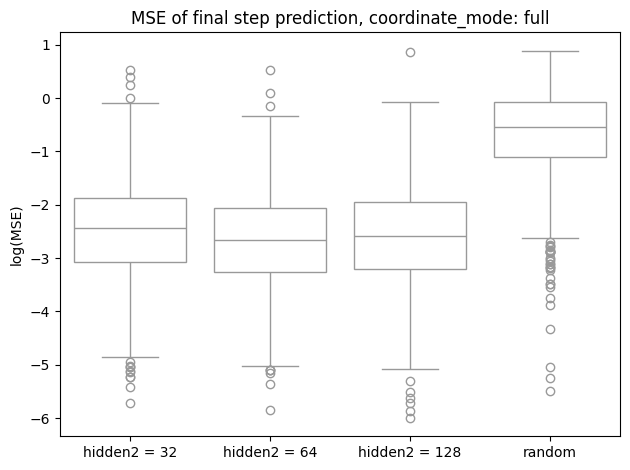

In [35]:
# Compare the differences between test set performance over different stepsize for rollout. 
#   in the future we can make rollout a choice - a separate node to determine rollout stepsize
#   for now and near future, we can stick with fixed unit rollout size and make RT fully dependent on the controller. 
import seaborn as sns
mode = "full"
if mode == "full" or mode == "binary":
    output_size = 3
else: 
    output_size = 2
training_args['data_loader_configs']['object_path'] = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
trainer.data_gen = trainer.data_generator(lean = False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})
test = trainer.data_gen.generate_data(1000)
candidate_hidden2 = [32, 64, 128]
mse = []
for hidden2 in candidate_hidden2: 
    stepped_model_additional_name = f"Linear_256_{hidden2}_cube" + (("_" + mode) if mode != "" else "")

    trainer.load_model(MODEL_SAVE_PATH + f"/forward_model_{loss}/FFModel_dynamics_0.07{stepped_model_additional_name}/model.pth", 1)
    trainer.model.eval()
    pred, enc, dec = trainer.model([test.z0, test.I, test.q])
    pred = pred.view(-1, 1, 8, output_size)
    enc = enc.view(-1, 5, 8, output_size)
    print(f"shape of pred: {pred.shape}")
    # append a np array of final MSE over the batch here: 
    mse.append(torch.log((pred[:, -1] - enc[:, -1]) ** 2).mean(dim = [1, 2]).cpu().detach().numpy())

rand = trainer.data_gen.generate_data(1000)
mse.append(torch.log((test.I[:, -1] - rand.I[:, -1]) ** 2).mean(dim = [1]).cpu().detach().numpy())
# Plot boxplot of the results
transparent_pallette = [(1, 1, 1, 0) for _ in range(len(candidate_hidden2) + 1)]
sns.set_palette(transparent_pallette)
sns.boxplot(mse)
plt.xticks(range(len(candidate_hidden2)+ 1), [*[f"hidden2 = {h2}" for h2 in candidate_hidden2], "random"])
plt.ylabel("log(MSE)")
plt.title("MSE of final step prediction, coordinate_mode: " + mode)
plt.tight_layout()
plt.savefig(FIG_PATH + f"/summary_internal_model/hidden2_mse_cube_{mode}.png")

# Controller design

Now that we have the network trained, we can think about the controller. 

GOAL: think about the controller as upstream processes pushing the motor cortex - an autonomous dynamical system - to a desired initial condition (Schimel, Kao, Hennequin 2024)

equations

$$
\tau \dot{\mathbf{x}} = -\mathbf{x} + \mathbf{I} + W \Delta \mathbf{x}\\
$$

Define an ideal rotation in image space, say $\mathbf{r}$; 

Problem: 

write the recurrent neural network function that leads from the current state to the (sliced) rotational trajectory (slice of length 1 gives you the final rotation) as:

$$
\mathbf{y} = f(\mathbf{x})
$$

From this relationship, design some function that minimizes controlling energy and mismatch energy:

$$
\begin{align}
\mathbf{I}(t) & = \mathbf{u}(t) + \epsilon_t\\
\text{let } \epsilon_t & = 0 \text{ for now}\\
\mathbf{}
\end{align}
$$

In [79]:
%load_ext autoreload
%autoreload 2
from Network_models.CTrainer import CTrainer
from SimulateDatasets.CubeMesh import CubeMesh
from utils.path_settings import *
tau = 100
dt = 1
resolution = 256
mode = "full"
model = torch.load(MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_2_train_10_8_cube_{mode}/model.pth")
model = model.predictor
cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
torch.save(cube, cube_path)
decoder_specs = None
additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") + "_pure_error_id_output"
batch_size = 8096
mini_batch_size = 512
model_specs = {
    "model_name": "ControlNet",
    "model_path": "Network_models.PIDController",
    "model_params":{
        "tau": tau, 
        "dt": dt, 
        "predictive_model": model,
        "output_size": 16 if mode == "camera_simple" else 24,
        "target_size": 200,
        "inject_inputs": False, 
        "recurrent_control": True,
        "pure_error": True, 
        "activation": "id",
        "readout_layer": False,
        "hidden_control_dim": 0, 
    }
}

dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
        "stepwise": True
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.001,
    }
}

data_loader_configs = {
    "batch_size": 8192,
    "mini_batch_size": 8192,
    "encoder_specs": None,
    "target_seq_len": 5,
    "object_path": cube_path,
}
model_path = f"/controller/{model_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "model_specs": model_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
    "control_period": 8,
    "random_initial_condition": True,
    "additional_loss": [], # choices: "state_norm", "control_norm", "state_likelihood"
    "data_loader_configs": data_loader_configs,
}

import time
print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}")
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 10,
    "epochs": 300, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data_stepwise_cube" + (("_" + mode) if mode != "" else "") +  "/",
    "verbose": True,
    "replacement_tolerance": 0.1,
}

trainer = CTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
print(f"tensorboard --logdir {config['log_path']}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
batch_size: 8096, mini_batch_size: 512
no scheduler
[]
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/controller/ControlNet_dynamics_0.07Linear_cube_full_pure_error_id_output//


In [80]:
trainer.train(**training_args)

batch_size: 8096, mini_batch_size: 512
Loading train_0.pth
8192
0
Loading val_0.pth
1024
0
Epoch 0, learning rate: 0.001
Epoch 0, training loss: 17.220726013183594, validation loss: 12.725250244140625
Epoch 1, training loss: 11.238531112670898, validation loss: 11.03877067565918
Epoch 2, training loss: 9.858572006225586, validation loss: 9.748695373535156
Epoch 3, training loss: 8.801399230957031, validation loss: 9.03955078125
Epoch 4, training loss: 8.22054672241211, validation loss: 8.618412017822266
Epoch 5, training loss: 7.78861141204834, validation loss: 8.46003532409668
Epoch 6, training loss: 7.445001125335693, validation loss: 7.925144195556641
Epoch 7, training loss: 7.144172191619873, validation loss: 7.495046615600586
Epoch 8, training loss: 6.952919006347656, validation loss: 7.380364418029785
Epoch 9, training loss: 6.782742023468018, validation loss: 7.130256652832031
Epoch 10, training loss: 6.589721202850342, validation loss: 6.8541059494018555
Epoch 11, training loss

In [21]:
trainer.load_checkpoint(config['check_path'] + "checkpoint249.pth")
trainer.save_model(config['save_path'] + "model.pth", full = 1)


In [1]:
constraints = [
    # [], 
    ['control_norm'],
    ["control_norm", "state_likelihood"],
    ["state_norm"],
    ["control_norm", "state_norm"]
    ]
# name_appendix = ["", "control_norm", "control_norm_state_likelihood", "state_norm", "control_norm_state_norm"]
name_appendix = ["control_norm", "control_norm_state_likelihood", "state_norm", "control_norm_state_norm"]
mode = "full"
for ind, loss in enumerate(constraints):
    tau = 100
    dt = 1
    resolution = 256
    model = torch.load(MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_2_train_10_8_cube_{mode}/model.pth")
    model = model.predictor
    cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
    cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
    torch.save(cube, cube_path)
    decoder_specs = None
    additional_name = f"Linear_cube" + (("_" + mode + "_") if mode != "" else "") + "_pure_error_id"+ name_appendix[ind]
    batch_size = 8096
    mini_batch_size = 512
    model_specs = {
        "model_name": "ControlNet",
        "model_path": "Network_models.PIDController",
        "model_params":{
            "tau": tau, 
            "dt": dt, 
            "predictive_model": model,
            "output_size": 16 if mode == "camera_simple" else 24,
            "target_size": 200,
            "inject_inputs": False, 
            "recurrent_control": True,
            "pure_error": False, 
            "activation": "id",
            "readout_layer": False,
            "hidden_control_dim": 0, 
        }
    }

    dynamics_model_specs = {
        "model_name": "DynamicalNetwork", 
        "model_path": "Network_models.DynamicalNetwork", 
        "model_params": {
            "output_size": 3, 
            "freeze_C": True, 
            "mode": "initial_condition", 
            "tau": tau,
            "dt": dt, 
            "seed": 10, 
            "total_period": 1000, 
            "action_period": 500, 
            "out_accel": True,
            "optimise_C": True,
            "automatically_plot": False, 
            "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
            "tau_accel": 50,
            "input_scalar": 0.07,
            "stepwise": True
        },
    }

    optimizer_specs = {
        "optimizer_name": "Adam",
        "optimizer_params": {
            "lr": 0.001,
        }
    }

    data_loader_configs = {
        "batch_size": 8192,
        "mini_batch_size": 8192,
        "encoder_specs": None,
        "target_seq_len": 5,
        "object_path": cube_path,
    }
    model_path = f"/controller/{model_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

    config = {
        "model_specs": model_specs,
        "dynamics_model_specs": dynamics_model_specs,
        "optimizer_specs": optimizer_specs,
        "save_path": MODEL_SAVE_PATH + model_path + "/",
        "check_path": MODEL_SAVE_PATH + model_path + "/",
        "log_path": LOG_PATH + model_path + "/",
        "control_period": 8,
        "random_initial_condition": True,
        "additional_loss": loss, # choices: "state_norm", "control_norm", "state_likelihood"
        "data_loader_configs": data_loader_configs,
    }

    import time
    print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}")
    training_args = {
        "batch_size": batch_size, 
        "mini_batch_size": mini_batch_size, 
        "epochs_to_calculate": 10,
        "epochs": 300, 
        "load_upper": 47,
        "save_interval": 10, 
        "reset_interval": 200,
        "early_stop": False,
        "data_save_path": DATA_PATH + f"/forward_model_data_stepwise_cube" + (("_" + mode) if mode != "" else "") +  "/",
        "verbose": True,
        "replacement_tolerance": 0.1,
    }

    trainer = CTrainer(config)
    time_start = time.time()

    for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
        os.makedirs(path, exist_ok = True)
    training_args['save_path'] = config["save_path"] + "model.pth"
    training_args["data_loader_configs"] = data_loader_configs
    print(f"tensorboard --logdir {config['log_path']}")
    trainer.train(**training_args)

NameError: name 'torch' is not defined

In [38]:
trainer.load_checkpoint(config['check_path'] + "checkpoint99.pth")
trainer.save_model(config['save_path'] + "model.pth", full = 1)

In [3]:
import matplotlib.pyplot as plt
# model = torch.load(MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_5_train_10_8_cube_{mode}{"_stepwise" if mode == "full" else ""}/model.pth")
# model = model.predictor
# trainer.data_gen = trainer.data_generator(lean = False, custom_configs=training_args["data_loader_configs"] | {"target_seq_len": 5})
# dynamics_network = trainer.data_gen.dynamics_network

model_name = "ControlNet"
input_scalar = 0.07
additional_constraint = ["state_norm"]
additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") +  ("_" if len(additional_constraint) > 0 else "") + "_pure_error_id" +"_".join(additional_constraint)
model_path = f"/controller/{model_name}_dynamics_{input_scalar}{additional_name if additional_name is not None else ""}/model.pth"
controller = torch.load(MODEL_SAVE_PATH + model_path)

# design a simple cube objective and see if the above controller works!
z0 = torch.zeros(1, 200, device = "cuda")
trainer.data_gen.cubemesh = True
target = trainer.data_gen.generate_data(1)
print(target.I.shape)
controller_results = controller.forward(z0, target.I[..., -1, :], control_period = 10, control_threshold = None, period_upperlimit = 10000, return_control_trajectory=True)
plt.plot(controller_results[2].cpu().detach().numpy().transpose())

FileNotFoundError: [Errno 2] No such file or directory: '/home/timmy/nonnormal/dummy/mental-rotations/saved_models/controller/ControlNet_dynamics_0.07Linear_cube_full__pure_error_idstate_norm/model.pth'

torch.Size([200, 200])
torch.Size([200])


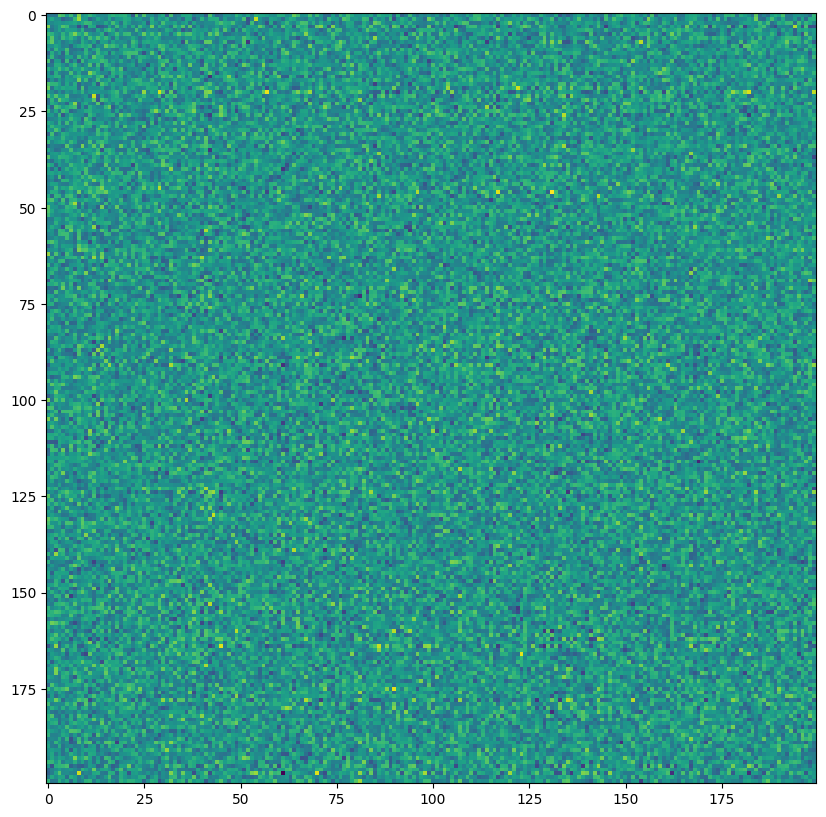

In [84]:
params = list(controller.W_hh.parameters())
for param in params:
    print(param.shape)
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
param = params[0].cpu().detach().numpy()
ax.imshow(param)

In [40]:
from scipy.spatial.transform import Rotation as R 
def q2euler(q):
    r = R.from_quat(q.cpu().detach().numpy().reshape(-1, 4), scalar_first=True)
    return r.as_euler('zyx', degrees=True)


Output acceleration
tensor([9.3236], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Output acceleration
Output acceleration


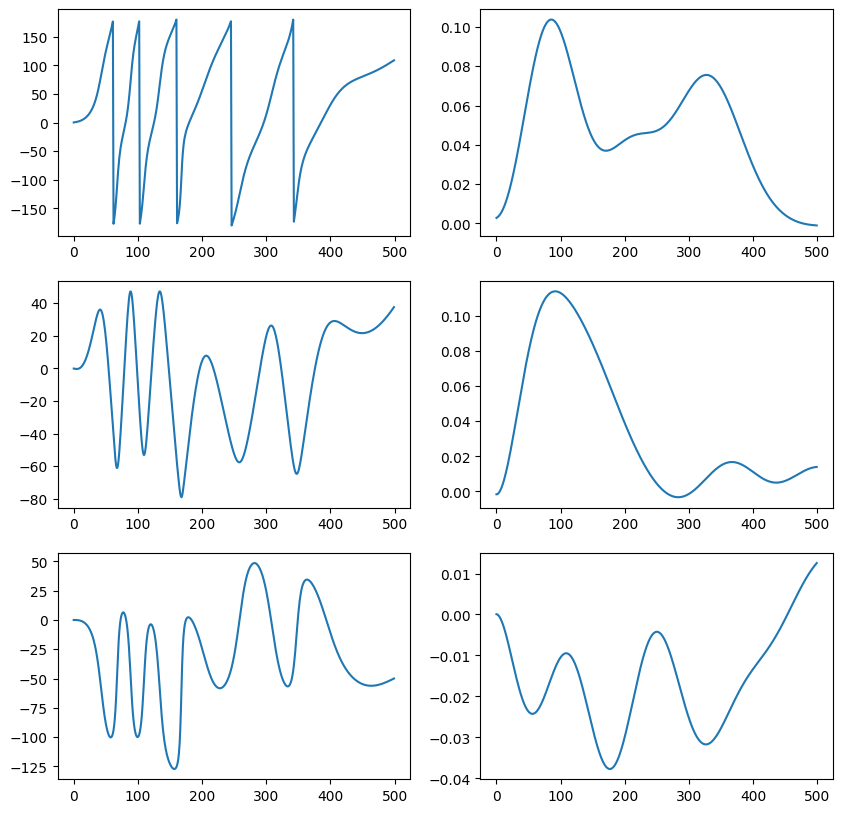

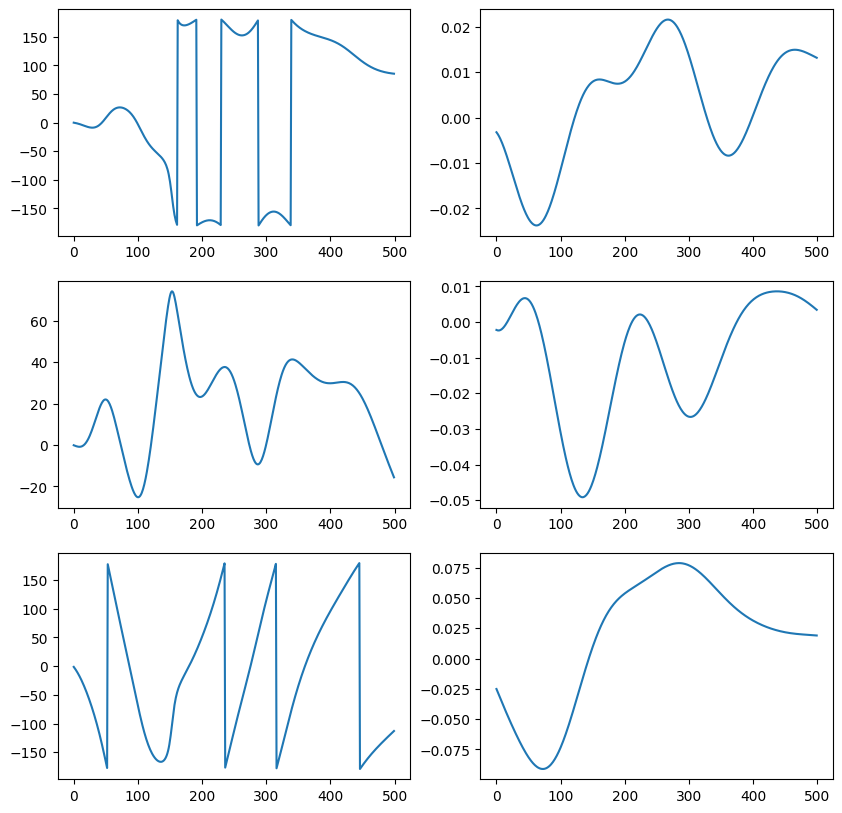

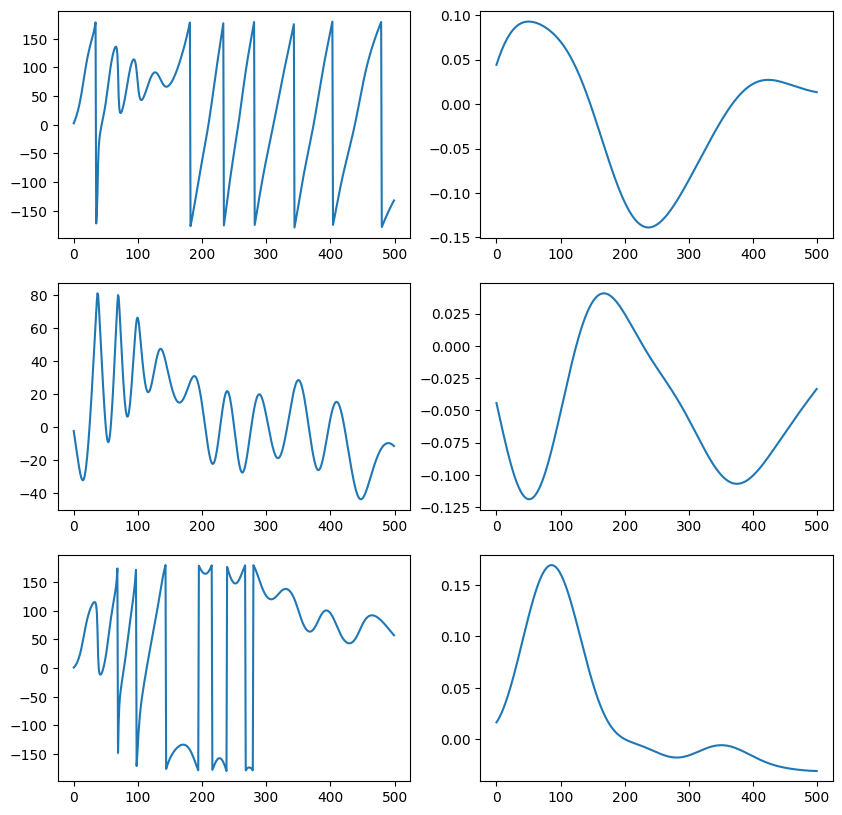

In [87]:
z0 = torch.randn(1, 200, device = "cuda")
# q_target = torch.randn(1, 4, device = "cuda")
# q_target = q_target / q_target.norm(p = 2, dim = -1, keepdim = True)
I = controller.mesh.quat2verts(q_target)

map_i = lambda x: x if x == 1 else (0 if x == 2 else 2)
# try letting it evolve and see the outcome quaternion: 
out = controller.dynamics_model(z0)
q = controller.dynamics_model.pred
fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())

z1 = controller.W_hh(z0)
print(z1.norm(p = 2, dim = -1))

out = controller.dynamics_model(z1.detach())
q = controller.dynamics_model.pred
fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())

returned = controller.evaluate_q(q_target, control_period = 4, random_init=z0)

z2 = returned['z0']
out = controller.dynamics_model(z2.detach())
q = controller.dynamics_model.pred

fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())


Output acceleration
tensor([23.6480], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Output acceleration
Output acceleration


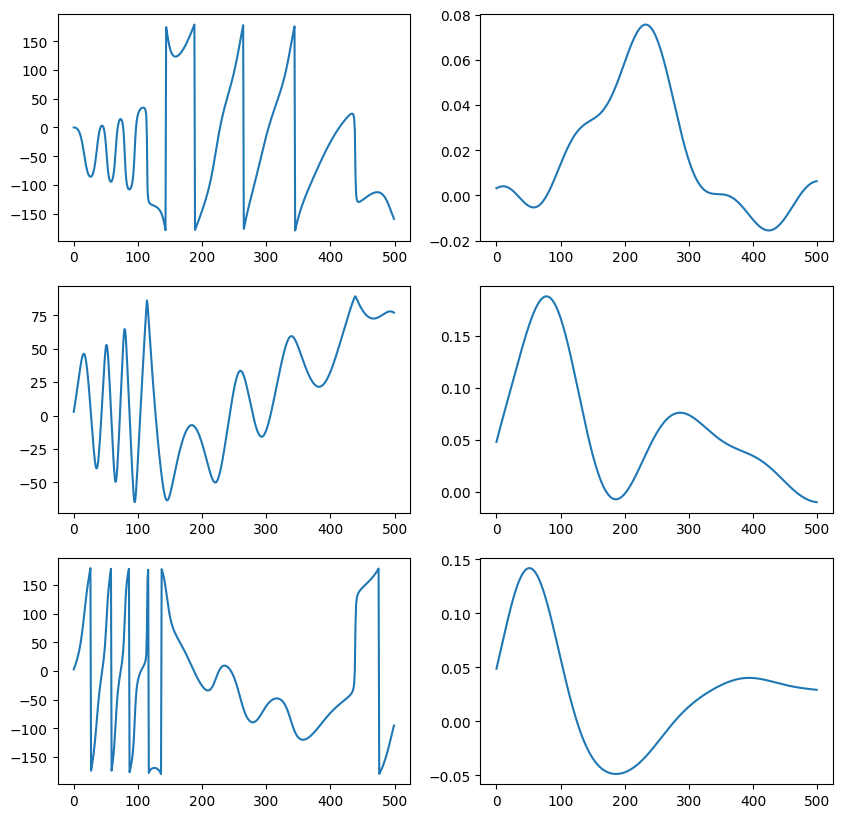

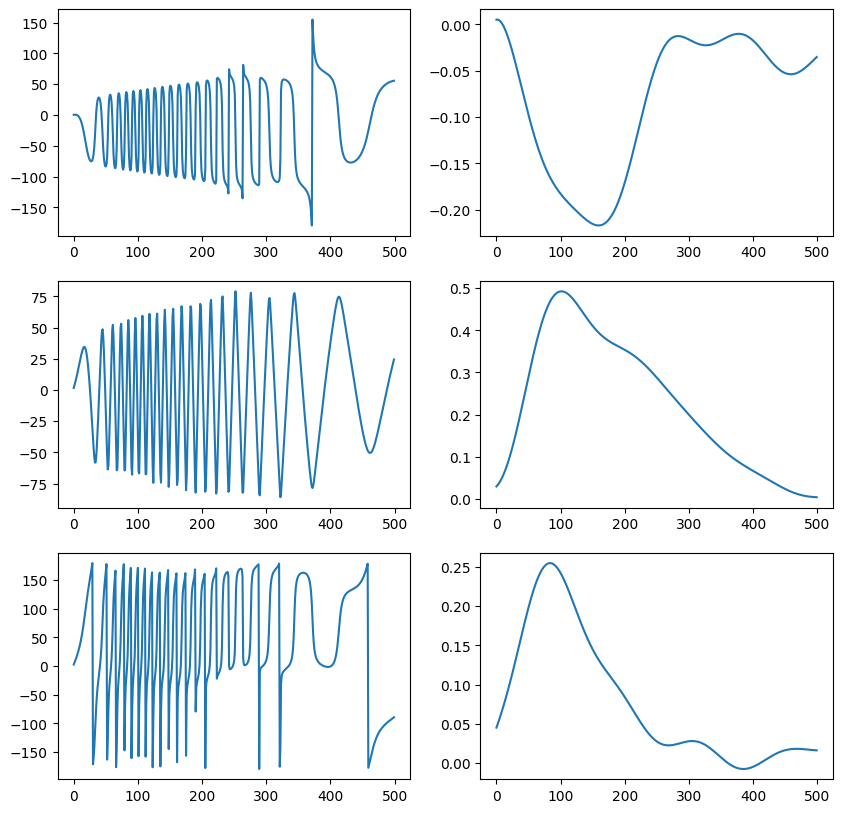

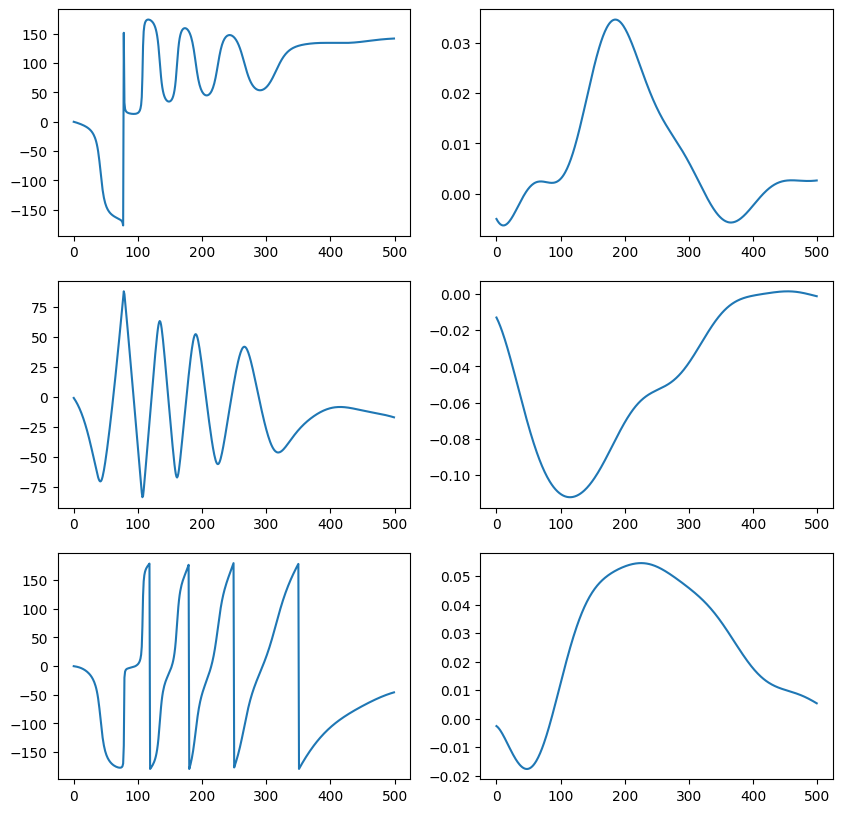

In [64]:
# z0 = torch.randn(1, 200, device = "cuda")
# q_target = torch.randn(1, 4, device = "cuda")
# q_target = q_target / q_target.norm(p = 2, dim = -1, keepdim = True)
# I = controller.mesh.quat2verts(q_target)

map_i = lambda x: x if x == 1 else (0 if x == 2 else 2)
# try letting it evolve and see the outcome quaternion: 
out = controller.dynamics_model(z0)
q = controller.dynamics_model.pred
fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())

z1 = controller.W_hh(z0)
print(z1.norm(p = 2, dim = -1))

out = controller.dynamics_model(z1.detach())
q = controller.dynamics_model.pred
fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())

returned = controller.evaluate_q(q_target, control_period = 16, random_init=z0)

z2 = returned['z0']
out = controller.dynamics_model(z2.detach())
q = controller.dynamics_model.pred

fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())


Output acceleration


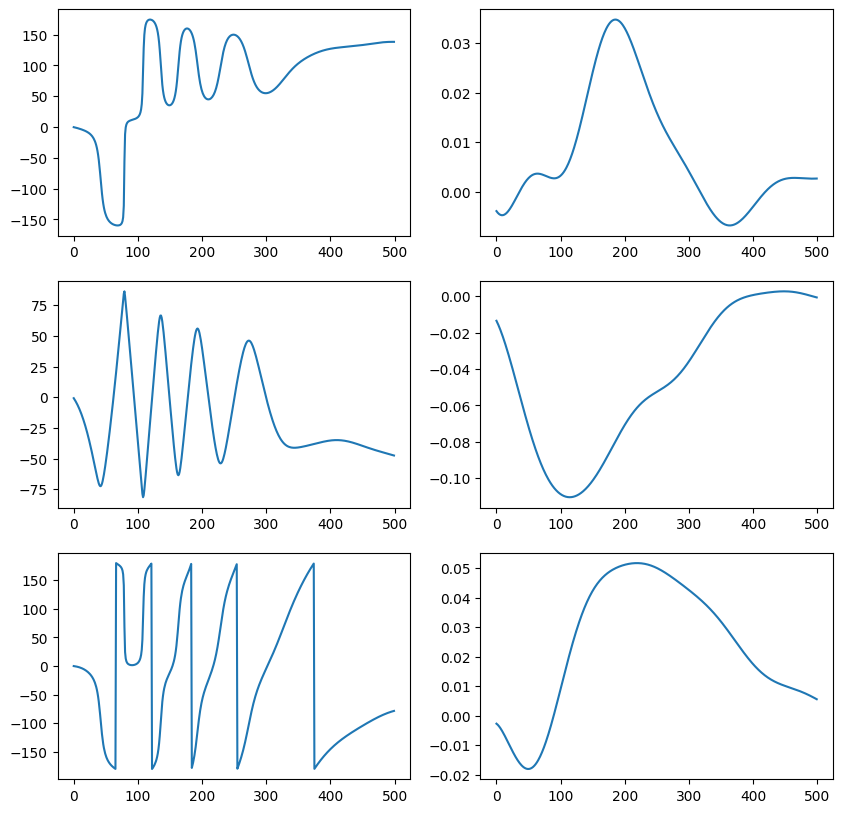

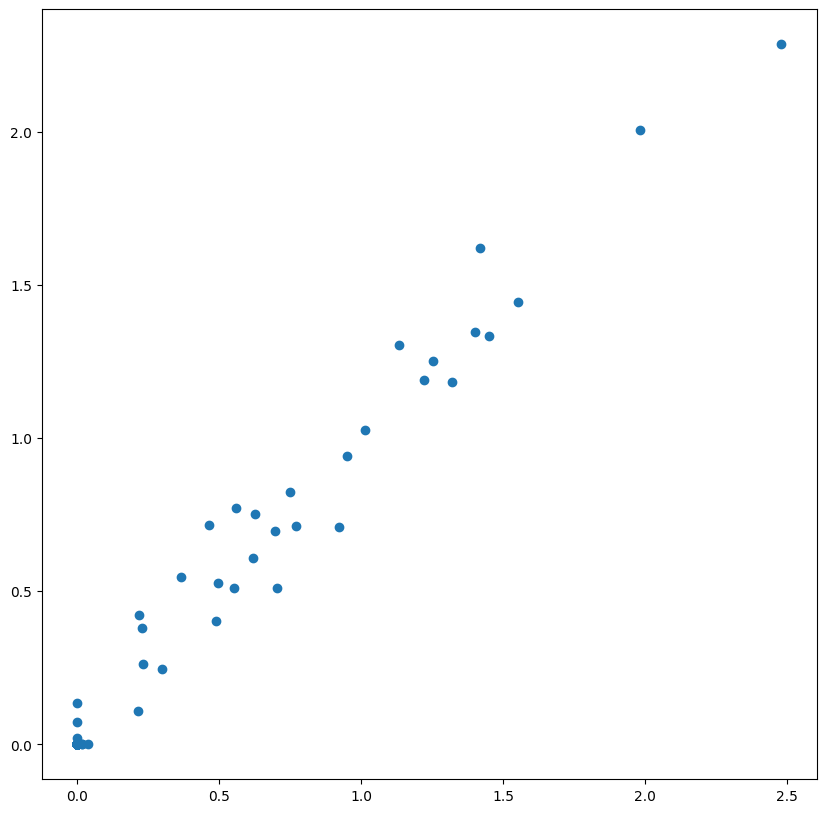

In [77]:
z3 = z2
zeros = torch.zeros_like(I)
z3 = controller.output(controller.activation(controller.W_hh(z3)))# + controller.W_xh(zeros)))
out = controller.dynamics_model(z3.detach())
q = controller.dynamics_model.pred

fig, axs = plt.subplots(3, 2, figsize = (10, 10))

#plot the three channels
for i in range(3):
    axs[i, 0].plot(q2euler(q)[:, i])
    axs[i, 1].plot(out[0, :, map_i(i)].cpu().detach().numpy())

fig, ax = plt.subplots(1, 1, figsize = (10, 10))
plt.scatter(z2.cpu().detach().numpy(), z3.cpu().detach().numpy())

In [29]:
print(target.q.shape)
traj = controller.rotate(target.q[:, -1, :])
print(f"traj shape {traj.shape}")
print(traj)
print(f"pred shape {controller.pred.shape}")

torch.Size([1, 5, 4])
Output acceleration
traj shape torch.Size([500, 4])
tensor([[ 1.0000e+00,  6.9931e-05,  7.0891e-05, -8.0182e-05],
        [ 1.0000e+00,  7.3322e-05,  7.4414e-05, -8.4373e-05],
        [ 1.0000e+00,  7.6556e-05,  7.7864e-05, -8.8664e-05],
        ...,
        [ 1.0000e+00,  1.0734e-04, -8.0565e-05,  2.0541e-06],
        [ 1.0000e+00,  1.0569e-04, -8.0820e-05,  3.4225e-06],
        [ 1.0000e+00,  1.0408e-04, -8.1076e-05,  4.7923e-06]], device='cuda:0')
pred shape torch.Size([1, 500, 4])


In [ ]:
import matplotlib.pyplot as plt
model_name = "ControlNet"
mode = "full"
additional_constraint = ["control_norm", "state_likelihood"]
additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") + "_pure_error_inject_inputs" + ("_" if len(additional_constraint) > 0 else "") + "_".join(additional_constraint)
model_path = f"/controller/{model_name}_dynamics_{input_scalar}{additional_name if additional_name is not None else ""}/model.pth"
controller = torch.load(MODEL_SAVE_PATH + model_path)

# target = trainer.data_gen.mesh.quat2verts(target.q.view(-1, 4)[-1, :], mode)
q = torch.tensor([0.0031226203, 0.5549813, 0.67362696, 0.48807043]).unsqueeze(0)
q = torch.tensor([0.11038378, -0.11381742, 0.5947715, 0.78810394]).unsqueeze(0)
target = trainer.data_gen.mesh.quat2verts(q, mode)

targ_view = target.view(-1, 8, 3) if mode != "camera_simple" else target.view(-1, 8, 2)

results = controller.evaluate_q(q, returned_list = ["control_traj", "error_traj", "I_pred"], random_init = True)

predicted = results['I_pred'].view(-1, 8, 3) if mode != "camera_simple" else results['I_pred'].view(-1, 8, 2)
control_traj = results['control_traj']
error_traj = results['error_traj']

fig, axs = plt.subplots(2, 2, figsize = (10, 10))
if mode != "camera_simple":
    axs[0, 0].scatter(-targ_view[0, :, 0].cpu().numpy(), targ_view[0, :, 1].cpu().numpy(), c = targ_view[0, :, 2].cpu().numpy())
    axs[0, 1].scatter(-predicted[0, :, 0].cpu().numpy(), predicted[0, :, 1].cpu().numpy(), c = predicted[0, :, 2].cpu().numpy())
else: 
    axs[0, 0].scatter(-targ_view[0, :, 0].cpu().numpy(), targ_view[0, :, 1].cpu().numpy())
    axs[0, 1].scatter(-predicted[0, :, 0].cpu().numpy(), predicted[0, :, 1].cpu().numpy())

axs[1, 0].plot(control_traj.cpu().detach().numpy().transpose())
axs[1, 1].plot(error_traj.cpu().detach().numpy().transpose())

Generating 1 samples
Output acceleration
Time for forward network dynamics : 0.11126518249511719
Time for rendering the dataset: 0.002077817916870117
torch.Size([1, 16, 200])
Output acceleration
tensor([[[-6.4448e-04,  4.5189e-04,  1.7764e-04],
         [-6.7858e-04,  4.7456e-04,  1.8594e-04],
         [-7.1375e-04,  4.9691e-04,  1.9353e-04],
         ...,
         [-2.0232e-04,  7.1126e-04, -7.6547e-05],
         [-1.9408e-04,  7.0912e-04, -8.2215e-05],
         [-1.8597e-04,  7.0687e-04, -8.7730e-05]]], device='cuda:0')


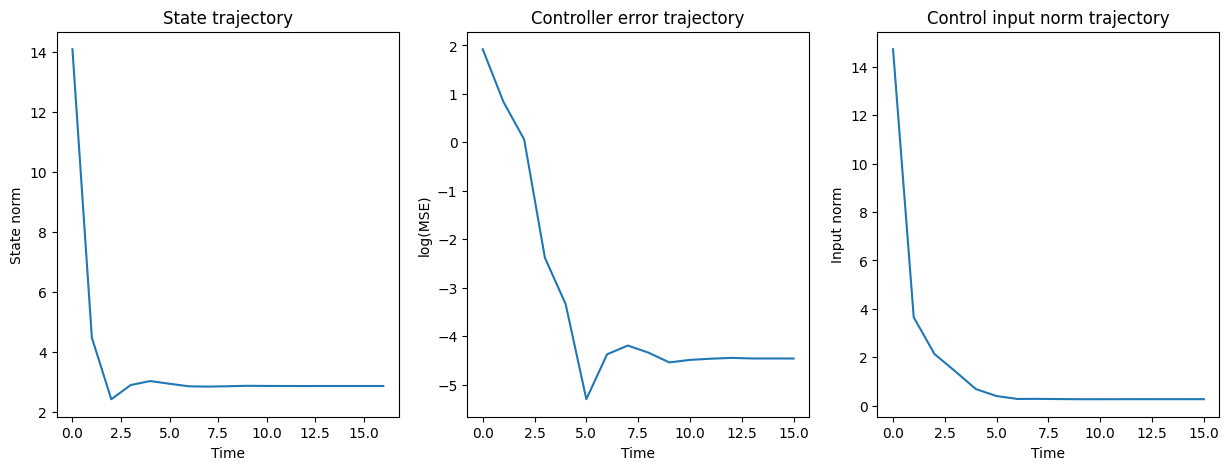

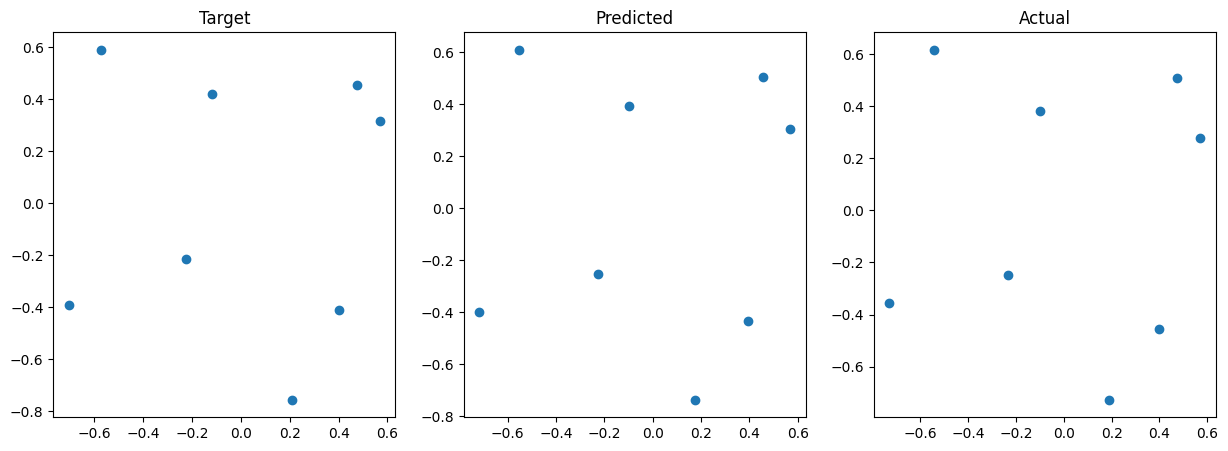

In [31]:
import numpy as np
z0 = torch.randn(1, 200, device = "cuda")
trainer.data_gen.cubemesh = True
target = trainer.data_gen.generate_data(1)

fig, ax1 = plt.subplots(1, 3, figsize = (15, 5))

controller_results = controller.forward(z0, target.I[..., -1, :], control_period = 16, control_threshold = None, period_upperlimit = 10000, return_control_trajectory=True)
ax1[0].plot(controller_results[0].norm(dim=-1).cpu().detach().numpy().transpose())
ax1[0].set_title("State trajectory")
ax1[0].set_ylabel("State norm")
ax1[0].set_xlabel("Time")

ax1[1].plot(np.log(controller_results[2].cpu().detach().numpy().transpose()))
ax1[1].set_title("Controller error trajectory")
ax1[1].set_ylabel("log(MSE)")
ax1[1].set_xlabel("Time")

print(controller_results[1].shape)
# also plot the control magnitude and x magnitude
ax1[2].plot((controller_results[1].norm(dim=-1).cpu().detach().numpy().transpose()))
ax1[2].set_title("Control input norm trajectory")
ax1[2].set_ylabel("Input norm")
ax1[2].set_xlabel("Time")

# see the actual rotation vs. a rotation from the controller: 
shape = (5, 8, 3) if mode != "camera_simple" else (5, 8, 2)
pred_out = model(controller_results[0][:, -1, :].detach()).reshape(*shape)[-1,...].detach()
out = dynamics_network(controller_results[0][:, -1, :].detach() * dynamics_network.input_scalar)
q = dynamics_network.pred[:, -1, :].detach()
if mode != "camera_simple":
    I = trainer.data_gen.mesh.quat2verts(q/q.norm(dim = -1, keepdim = True), mode).reshape(8, 3)
    targ = target.I[..., -1, :].reshape(8, 3)

    #plot the actual rotation
    fig, ax = plt.subplots(1, 3, figsize = (15, 5))
    ax[0].scatter(targ[:, 0].cpu().numpy(), targ[:, 1].cpu().numpy(), c = targ[:, 2].cpu().numpy())
    ax[0].set_title("Target")

    ax[1].scatter(pred_out[:, 0].cpu().numpy(), pred_out[:, 1].cpu().numpy(), c = pred_out[:, 2].cpu().numpy())
    ax[1].set_title("Predicted")

    ax[2].scatter(I[:, 0].cpu().numpy(), I[:, 1].cpu().numpy(), c = I[:, 2].cpu().numpy())
    ax[2].set_title("Actual")
else: 
    I = trainer.data_gen.mesh.quat2verts(q/q.norm(dim = -1, keepdim = True), mode).reshape(8, 2)
    targ = target.I[..., -1, :].reshape(8, 2)

    #plot the actual rotation
    fig, ax = plt.subplots(1, 3, figsize = (15, 5))
    ax[0].scatter(targ[:, 0].cpu().numpy(), targ[:, 1].cpu().numpy())
    ax[0].set_title("Target")

    ax[1].scatter(pred_out[:, 0].cpu().numpy(), pred_out[:, 1].cpu().numpy())
    ax[1].set_title("Predicted")

    ax[2].scatter(I[:, 0].cpu().numpy(), I[:, 1].cpu().numpy())
    ax[2].set_title("Actual")

In [33]:
%load_ext autoreload
%autoreload 2
from Network_models.CTrainer import CTrainer
from SimulateDatasets.CubeMesh import CubeMesh
from utils.path_settings import *

tau = 100
dt = 1
resolution = 256
dT = 500/32
mode = "full"
model = torch.load(MODEL_SAVE_PATH + f"/forward_model_Predictor-MSEGradual/FastRecurrence_dynamics_0.07input_time_1_silence_2_train_10_8_cube_{mode}/model.pth")
model = model.predictor
cube_path = OBJECT_PATH + f"/cube_mesh/cube_mesh_{mode}.pth"
cube = CubeMesh(resolution = resolution, camera_position=torch.tensor([0, 0, 5]), default_mode = mode)
torch.save(cube, cube_path)
decoder_specs = None
additional_name = f"Linear_cube" + (("_" + mode) if mode != "" else "") + "_pure_error_id_output"
batch_size = 8096
mini_batch_size = 512
model_specs = {
    "model_name": "ControlInjectNet",
    "model_path": "Network_models.PIDController",
    "model_params":{
        "tau": tau, 
        "dt": dt, 
        "dT": dT,
        "predictive_model": model,
        "output_size": 16 if mode == "camera_simple" else 24,
        "target_size": 200,
        "pure_error": True, 
        "activation": "id",
        "hidden_control_dim": 64, 
    }
}

dynamics_model_specs = {
    "model_name": "DynamicalNetwork", 
    "model_path": "Network_models.DynamicalNetwork", 
    "model_params": {
        "output_size": 3, 
        "freeze_C": True, 
        "mode": "initial_condition", 
        "tau": tau,
        "dt": dt, 
        "seed": 10, 
        "total_period": 1000, 
        "action_period": 500, 
        "out_accel": True,
        "optimise_C": True,
        "automatically_plot": False, 
        "accel_leak_method": 2, # 0: None; 1: exponential window; 2: exponential filter
        "tau_accel": 50,
        "input_scalar": 0.07,
        "stepwise": True
    },
}

optimizer_specs = {
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.001,
    }
}

data_loader_configs = {
    "batch_size": 8192,
    "mini_batch_size": 8192,
    "encoder_specs": None,
    "target_seq_len": 5,
    "object_path": cube_path,
}
model_path = f"/controller/{model_specs['model_name']}_dynamics_{dynamics_model_specs['model_params']['input_scalar']}{additional_name if additional_name is not None else ""}/"

config = {
    "model_specs": model_specs,
    "dynamics_model_specs": dynamics_model_specs,
    "optimizer_specs": optimizer_specs,
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
    "control_period": 32,
    "random_initial_condition": True,
    "additional_loss": [], # choices: "state_norm", "control_norm", "state_likelihood"
    "data_loader_configs": data_loader_configs,
}

import time
print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}")
training_args = {
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 10,
    "epochs": 300, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "data_save_path": DATA_PATH + f"/forward_model_data_stepwise_cube" + (("_" + mode) if mode != "" else "") +  "/",
    "verbose": True,
    "replacement_tolerance": 0.1,
}

trainer = CTrainer(config)
time_start = time.time()

for path in [config["save_path"], config["check_path"], config["log_path"], training_args["data_save_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = config["save_path"] + "model.pth"
training_args["data_loader_configs"] = data_loader_configs
print(f"tensorboard --logdir {config['log_path']}")
trainer.train(**training_args)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
batch_size: 8096, mini_batch_size: 512
no scheduler
[]
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/controller/ControlInjectNet_dynamics_0.07Linear_cube_full_pure_error_id_output//


In [37]:
trainer.train(**training_args)

batch_size: 8096, mini_batch_size: 512
Loading train_0.pth
8192
0
Loading val_0.pth
1024
0
512


OutOfMemoryError: CUDA out of memory. Tried to allocate 602.00 MiB. GPU 

# the above is way too slow. Let's perform some analyses over several ways to speed up. 

1. this may be because the predictor part of the network is not unrolled.
    test: a toy network forward pass vs. unrolled forward pass. (do a time sequence of like 5 steps and 1000 passes forward)
2. this may be because the various matrices in the predictor part of the network are still recognised as parameters (even though the network is not to be mutated)
    test: set the parameters to be regular tensors. 
3. this may be because the for loops are handled slowly (and I may remedy this slowness by writing it in cuda)
    test: do a toy comparison with rnns, straightforward implementation vs. optimised implementation

In [16]:
class GRU_network(nn.Module):
    def __init__(self, repeats): 
        super(GRU_network, self).__init__()
        self.networks = [nn.GRU(200, 200, batch_first = True) for _ in range(repeats)]

    def forward(self, x): 
        for network in self.networks:
            x, _ = network(x)
        return x

    def frozen_parameters(self):
        """returns another network instantiation where the parameters are presented as torch tensors"""

class GRU_network_untrainable: 
    def __init__(self, repeats):
        self.


steps = [1, 3, 5, 7, 10]
import time
for step in steps:
    network1 = GRU_network(1)
    network2 = GRU_network(step) 
    network1_in = torch.randn(1000, step, 200)
    network2_in = torch.randn(1000, 1, 200)
    start_time = time.time()
    _ = network1(network1_in)
    end_time = time.time()
    print(f"network1 took {end_time - start_time} seconds to process step {step} input")
    for param in network1.parameters():
        param.requires_grad = False
    start_time = time.time()
    _ = network1(network1_in)
    end_time = time.time()
    print(f"network1 took {end_time - start_time} seconds to process step {step} input without grad")

    start_time = time.time()
    _ = network2(network2_in)
    end_time = time.time()
    print(f"network2 took {end_time - start_time} seconds to process step {step} input")
    for param in network2.parameters():
        param.requires_grad = False

    start_time = time.time()
    _ = network2(network2_in)
    end_time = time.time()
    print(f"network2 took {end_time - start_time} seconds to process step {step} input")




network1 took 0.008937358856201172 seconds to process step 1 input
network1 took 0.0043792724609375 seconds to process step 1 input without grad
network2 took 0.0018334388732910156 seconds to process step 1 input
network2 took 0.002714395523071289 seconds to process step 1 input
network1 took 0.008296728134155273 seconds to process step 3 input
network1 took 0.008764266967773438 seconds to process step 3 input without grad
network2 took 0.0061070919036865234 seconds to process step 3 input
network2 took 0.006062746047973633 seconds to process step 3 input
network1 took 0.01007699966430664 seconds to process step 5 input
network1 took 0.011411666870117188 seconds to process step 5 input without grad
network2 took 0.012717247009277344 seconds to process step 5 input
network2 took 0.011629343032836914 seconds to process step 5 input
network1 took 0.01204824447631836 seconds to process step 7 input
network1 took 0.015324115753173828 seconds to process step 7 input without grad
network2 too

Test 1 result: not much difference, rolled vs. unrolled

In [4]:
import time
batch_size = 2048
class RNN_test_ground(nn.Module):
    def __init__(self, mode): 
        super(RNN_test_ground, self).__init__()
        self.rnn_pytorch = nn.RNN(200, 200, batch_first = True)
        self.input_size = 200
        self.mode = mode
        self.hidden_size = 200
        self.num_layers = 1
        
        # Define the input to hidden weights and hidden to hidden weights
        self.W_ih = nn.Linear(self.input_size, self.hidden_size)
        self.W_hh = nn.Linear(self.hidden_size, self.hidden_size)

    def forward(self, x, h0 = torch.zeros(1, batch_size, 200)):
        if self.mode != "pytorch":
            batch_size, seq_len, _ = x.size()
            h = h0
            
            outputs = []
            for t in range(seq_len):
                xt = x[:, t, :]
                h = torch.tanh(self.W_ih(xt) + self.W_hh(h))
                outputs.append(h)
            
            # Stack the outputs for all time steps
            outputs = torch.stack(outputs, dim=1)
           
            return outputs, h
        else: 
            return self.rnn_pytorch(x, h0)

class RNN_test_tensors(nn.Module):
    def __init__(self): 
        super(RNN_test_tensors, self).__init__()
        self.input_size = 200
        self.hidden_size = 200
        self.num_layers = 1
        
        # Define the input to hidden weights and hidden to hidden weights
        self.W_ih = torch.randn(self.input_size, self.hidden_size)
        self.b_ih = torch.randn(self.hidden_size)
        self.W_hh = torch.randn(self.hidden_size, self.hidden_size)
        self.b_hh = torch.randn(self.hidden_size)

    def forward(self, x, h0 = torch.zeros(1, batch_size, 200)):
        batch_size, seq_len, _ = x.size()
        h = h0
        
        outputs = []
        for t in range(seq_len):
            xt = x[:, t, :]
            h = torch.tanh(xt @ self.W_ih.T + self.b_ih + h @ self.W_hh.T  + self.b_hh)
            outputs.append(h)
        
        # Stack the outputs for all time steps
        outputs = torch.stack(outputs, dim=1)
        
        return outputs, h
        

    
# compare run times over 1000 steps: 
test = RNN_test_ground("pytorch")
in_test = torch.randn(batch_size, 1000, 200)

test_2 = RNN_test_tensors()
start_time = time.time()
_ = test_2(in_test)
end_time = time.time()
print(f"custom rnn took {end_time - start_time} time to process 1000 steps")

start_time = time.time()
_ = test(in_test)
end_time = time.time()
print(f"pytorch rnn took {end_time - start_time} time to process 1000 steps")

test.mode = "custom"

start_time = time.time()
_ = test(in_test)
end_time = time.time()
print(f"custom rnn took {end_time - start_time} time to process 1000 steps")


custom rnn took 1.1507275104522705 time to process 1000 steps
pytorch rnn took 1.3652300834655762 time to process 1000 steps
custom rnn took 1.3142459392547607 time to process 1000 steps


In [29]:
a = model(torch.randn(1, 200, device = "cuda"))
fig, axs = plt.subplots(2, 5, figsize = (20, 8))
a = a.reshape(1, 5, 8, 3)
for i in range(5):
    axs[0, i].scatter(a[0, i, :, 0].cpu().detach().numpy().transpose(), a[0, i, :, 1].cpu().detach().numpy().transpose())
    if i > 0: 
        axs[1, i].scatter((a[0, i, :, 0] - a[0, i - 1, :, 0]).cpu().detach().numpy().transpose(), (a[0, i, :, 1] - a[0, i - 1, :, 1]).cpu().detach().numpy().transpose())

NameError: name 'model' is not defined

In [46]:
# design a simple cube objective and see if the above controller works!
data_points = 32
z0 = torch.randn(data_points, 200, device = "cuda")
target = trainer.data_gen.generate_data(data_points)
import time
time_start = time.time()
controller_results = controller(z0, target.I[:, -1], control_period = 1024, control_threshold = None, period_upperlimit = 1000)
time_end = time.time()
print(f"it takes {time_end - time_start} seconds to run the controller for 1000 steps")
time_start = time.time()
controller_results = controller(z0, target.I[:, -1], control_period = 128, control_threshold = None, period_upperlimit = 1000)
time_end = time.time()
print(f"it takes {time_end - time_start} seconds to run the controller for 100 steps")
# plt.plot(controller_results[1].cpu().detach().numpy().transpose())

Generating 32 samples
Output acceleration
Time for forward network dynamics : 0.5621695518493652
Time for rendering the dataset: 0.0009906291961669922
Control period exceeded upper bound with residual error
it takes 4.036088705062866 seconds to run the controller for 1000 steps
it takes 0.642064094543457 seconds to run the controller for 100 steps


# Sensitivity analysis

So that didn't work! Let's try to see how sensitive the model is to initial conditions. 

Define metric: 
$$
S(q_out, z0_{i}) = \frac{\mathrm{D}_{Geod}(q_{out}(z0_{i}), q_{out}(z0_{i} + \epsilon))}{\epsilon}
$$

In [ ]:
def geod_d(q1: torch.tensor, q2: torch.tensor): 
    return 2 * torch.acos(torch.abs(torch.sum(q1 * q2, dim = -1)))


i = 0
initial_condition = network.sample_initial_condition(1, use_gramian = True)
zi = torch.randn(200, 1)
eps = 1e-3
initial_condition = initial_condition.repeat(200, 1)
initial_condition[:, 0] = zi[:, 0]
initial_condition_alt = initial_condition.clone()
initial_condition_alt[:, 0] = zi[:, 0] + eps

# evaluate network outputs for these cases: 
_ = network(initial_condition)
output = network.pred
_ = network(initial_condition_alt)
output_alt = network.pred


Output acceleration
Output acceleration


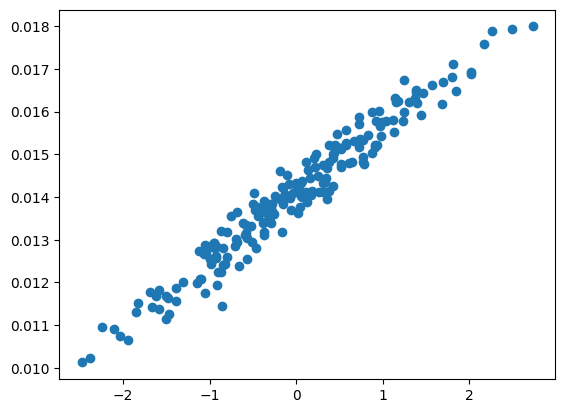

In [ ]:
# plot geodesic distance as a function of zi
a = geod_d(output, output_alt)
plt.scatter(zi.cpu().numpy(), a.cpu().numpy())

Output acceleration
Output acceleration
Output acceleration
Output acceleration


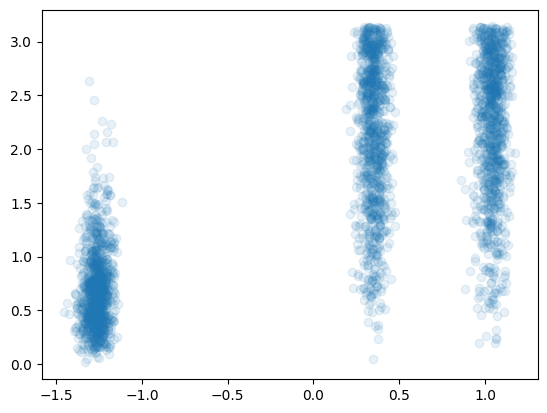

In [ ]:
def geod_d(q1: torch.tensor, q2: torch.tensor): 
    return 2 * torch.acos(torch.abs(torch.sum(q1 * q2, dim = -1)))


network = trainer.dynamics_model
initial_condition = network.sample_initial_condition(1000, use_gramian = True)*network.input_scalar
initial_condition_small_distance = initial_condition + network.sample_initial_condition(1000, use_gramian = True)* network.input_scalar
initial_condition_large_distance = initial_condition + network.sample_initial_condition(1000, use_gramian = True) * network.input_scalar * 0.1
initial_condition_larger_distance = initial_condition + network.sample_initial_condition(1000, use_gramian = True) * network.input_scalar * 0.5

# evaluate network outputs for these cases: 
_ = network(initial_condition)
output_orig = network.pred
_ = network(initial_condition_small_distance)

output_small_distance = network.pred
_ = network(initial_condition_large_distance)
output_large_distance = network.pred
_ = network(initial_condition_larger_distance)
output_larger_distance = network.pred

# plot geodesic distance as a function of input distance
Geod_distance_small = geod_d(output_orig, output_small_distance)
# input distance
zi_small = torch.norm(initial_condition - initial_condition_small_distance, p = 2, dim = -1)

Geod_distance_large = geod_d(output_orig, output_large_distance)
zi_large = torch.norm(initial_condition - initial_condition_large_distance, p = 2, dim = -1)

Geod_distance_larger = geod_d(output_orig, output_larger_distance)
zi_larger = torch.norm(initial_condition - initial_condition_larger_distance, p = 2, dim = -1)

geod = torch.cat([Geod_distance_small, Geod_distance_large, Geod_distance_larger])
zi = torch.cat([zi_small, zi_large, zi_larger])

plt.scatter(np.log(zi.cpu().numpy()), geod.cpu().numpy(), alpha = 0.1)

# Treat Below as for archive purposes only

Output acceleration
Output acceleration


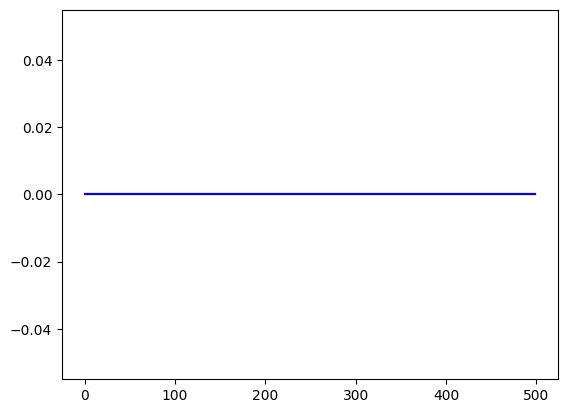

In [ ]:
net = torch.load(MODEL_SAVE_PATH + "/dynamics_network.pth")
traj = net.rotate('whatever')
net(0 * net.sample_initial_condition(1000, use_gramian = True))
colors = ["r", "g", "b"]
fig, ax = plt.subplots()
for j in range(3):
    ax.plot(
        net.out[0, :, j].cpu().detach().numpy(),
        c=colors[j],
    )
plt.show()

In [ ]:
import plotly.colors as pc
pc.sample_colorscale("GnBu", [0.1])

['rgb(229, 245, 223)']

In [ ]:
data = torch.randn(1000, 1, 64, 64)
d_centered = data.view(-1, 64 * 64) - data.view(-1, 64 * 64).mean(dim = 0)
d_centered.shape

torch.Size([1000, 4096])



Values:


/home/tim/dummy/mental-rotations/Plots/globe_plots.py:704: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.

/home/tim/dummy/mental-rotations/Plots/globe_plots.py:704: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



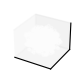

1, 1


In [ ]:
def sample_uniform_sphere(n_samples):
    """Samples a point uniformly on the unit sphere."""

    z = np.random.uniform(-1, 1, n_samples)
    phi = np.random.uniform(0, 2*np.pi, n_samples)
    r = np.sqrt(1 - z**2)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return np.stack([x, y, z], axis = -1)

theta = np.random.uniform(-np.pi, np.pi, 1000).reshape(-1, 1)
u = sample_uniform_sphere(1000)
u = u / np.linalg.norm(u, axis = 1, keepdims = True)
xs = 0.5 * u * theta
# Y = np.random.randn(xs.shape[0], 1)
Y = [np.ones((xs.shape[1]))]
gp.plot_generic(xs, Y, ["Final rotations"], show = True, colorscale = "gnbu")

In [ ]:
gp.globe_histogram(xs, 10, "GnBu")

In [ ]:
class test_object1:
    def __init__(self, **kwargs): 
        self.obj = kwargs.get("b")

class test_object2:
    def __init__(self, a): 
        self.attribute = a

args = {
    "b": test_object2(1)
}
test_1 = test_object1(**args)
obj2 = getattr(test_1, "obj")
setattr(obj2, "attribute", 2)
test_1.obj.attribute

2